### 1.1 Verificación del acelerador disponible

In [1]:
# Verificar GPU desde el sistema operativo
!nvidia-smi


Sat Jun  6 18:19:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2 Instalación de dependencias

In [2]:
# Instalar JAX con soporte CUDA (GPU), Flax NNX y Optax
!pip install -q --upgrade "jax[cuda12]" flax optax

# Verificar versiones instaladas
import importlib
for lib in ["jax", "flax", "optax"]:
    try:
        m = importlib.import_module(lib)
        print(f"  {lib:10s}: {m.__version__}")
    except Exception as e:
        print(f"  {lib:10s}: ERROR — {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.1/525.1 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 9.7 MB/s eta 0:00:00
  jax       : 0.10.1
  flax      : 0.12.7
  optax     : 0.2.8


### 1.3 Verificación de dispositivos JAX

In [3]:
import jax
import jax.numpy as jnp

# Dispositivos disponibles para JAX
print("Dispositivos disponibles:")
print(" ", jax.devices())
print()
print(f"Cantidad de dispositivos : {jax.device_count()}")
print(f"Backend en uso           : {jax.default_backend()}")
print(f"Versión de JAX           : {jax.__version__}")

# Prueba rápida de operación en GPU
x = jnp.ones((1000, 1000))
resultado = jnp.dot(x, x)
print()
print(f"Prueba de multiplicación matricial (1000×1000):")
print(f"  Dispositivo usado : {resultado.device}")
print(f"  Resultado[0,0]    : {resultado[0, 0]:.1f}  (esperado: 1000.0)")

Dispositivos disponibles:
  [CudaDevice(id=0)]

Cantidad de dispositivos : 1
Backend en uso           : gpu
Versión de JAX           : 0.10.1

Prueba de multiplicación matricial (1000×1000):
  Dispositivo usado : cuda:0
  Resultado[0,0]    : 1000.0  (esperado: 1000.0)


### 1.4 Configuración de credenciales Kaggle

Kaggle ahora usa **tokens de API** en lugar del archivo `kaggle.json` clásico.  

**Para obtener tu token:**
1. Ve a **https://www.kaggle.com** → tu perfil → **Settings** → pestaña **Tokens de API**
2. Clic en **"Generar nuevo token"**
3. Copia el token que aparece (empieza con `KGAT_...`)
4. Copia también tu nombre de usuario (aparece en la URL de tu perfil: `kaggle.com/tunombre`)
5. Pega ambos valores en la celda siguiente


In [4]:
import os
import json

# ── COMPLETA ESTOS DOS DATOS ──────────────────────────────────────────────
KAGGLE_USERNAME = "DavidMora0"    # nombre de usuario en kaggle.com
KAGGLE_TOKEN    = "KGAT_eb1cbc81e4902abba34705dacc580f0a"      # token
# ─────────────────────────────────────────────────────────────────────────

# Validar que el usuario completó los datos
assert KAGGLE_USERNAME != "TU_USUARIO_AQUI", "Completa KAGGLE_USERNAME con tu usuario de Kaggle"
assert KAGGLE_TOKEN    != "TU_TOKEN_AQUI",   "Completa KAGGLE_TOKEN con tu token de API"

# Crear kaggle.json con los datos ingresados
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

credenciales = json.dumps({"username": KAGGLE_USERNAME, "key": KAGGLE_TOKEN})

for ruta in ["/root/.config/kaggle/kaggle.json",
             os.path.expanduser("~/.kaggle/kaggle.json")]:
    with open(ruta, "w") as f:
        f.write(credenciales)

!chmod 600 /root/.config/kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print(f"Credenciales configuradas correctamente.")
print(f"  Usuario : {KAGGLE_USERNAME}")
print(f"  Token   : {KAGGLE_TOKEN[:8]}{'*' * (len(KAGGLE_TOKEN) - 8)}")


Credenciales configuradas correctamente.
  Usuario : DavidMora0
  Token   : KGAT_eb1*****************************


### 1.5 Descarga del dataset desde Kaggle

In [5]:
import os

DATASET_DIR = "/content/wonders"
os.makedirs(DATASET_DIR, exist_ok=True)

# URL CORRECTA del dataset
print("Descargando dataset desde Kaggle...")
!kaggle datasets download -d balabaskar/wonders-of-the-world-image-classification \
    -p /content --quiet

# Localizar el ZIP descargado
zips = [f for f in os.listdir("/content") if f.endswith(".zip")]
print(f"Archivos ZIP encontrados: {zips}")

if zips:
    zip_real = f"/content/{zips[0]}"
    print(f"\nDescomprimiendo {zip_real} → {DATASET_DIR}")
    !unzip -q "{zip_real}" -d "{DATASET_DIR}"
    print("Descompresión completada.")
else:
    print("No se encontró ZIP. Verifica tus credenciales de Kaggle.")


Descargando dataset desde Kaggle...
Dataset URL: https://www.kaggle.com/datasets/balabaskar/wonders-of-the-world-image-classification
License(s): CC0-1.0
Archivos ZIP encontrados: ['wonders-of-the-world-image-classification.zip']

Descomprimiendo /content/wonders-of-the-world-image-classification.zip → /content/wonders
Descompresión completada.


### 1.6 Exploración de la estructura del dataset

In [6]:
import os

# Detectar la carpeta raíz con las clases automáticamente
raiz = DATASET_DIR
for _ in range(3):
    contenido = os.listdir(raiz)
    carpetas  = [c for c in contenido
                 if os.path.isdir(os.path.join(raiz, c))]
    if len(carpetas) >= 5:
        break
    if len(carpetas) == 1:
        raiz = os.path.join(raiz, carpetas[0])
    else:
        break

CLASES    = sorted(carpetas)
DATA_ROOT = raiz

print(f"Ruta raíz del dataset : {DATA_ROOT}")
print(f"Clases encontradas    : {len(CLASES)}")
print()

total = 0
for clase in CLASES:
    ruta_clase = os.path.join(DATA_ROOT, clase)
    n = len([f for f in os.listdir(ruta_clase)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    total += n
    print(f"  {clase:<30s}: {n:4d} imágenes")

print(f"  {'':30s}  ------")
print(f"  {'TOTAL':<30s}: {total:4d} imágenes")


Ruta raíz del dataset : /content/wonders/Wonders of World/Wonders of World
Clases encontradas    : 12

  burj_khalifa                  :  390 imágenes
  chichen_itza                  :  340 imágenes
  christ_the_reedemer           :  323 imágenes
  eiffel_tower                  :  391 imágenes
  great_wall_of_china           :  392 imágenes
  machu_pichu                   :  393 imágenes
  pyramids_of_giza              :  372 imágenes
  roman_colosseum               :  394 imágenes
  statue_of_liberty             :  238 imágenes
  stonehenge                    :  204 imágenes
  taj_mahal                     :  158 imágenes
  venezuela_angel_falls         :  251 imágenes
                                  ------
  TOTAL                         : 3846 imágenes


### 1.7 Visualización de muestras por clase

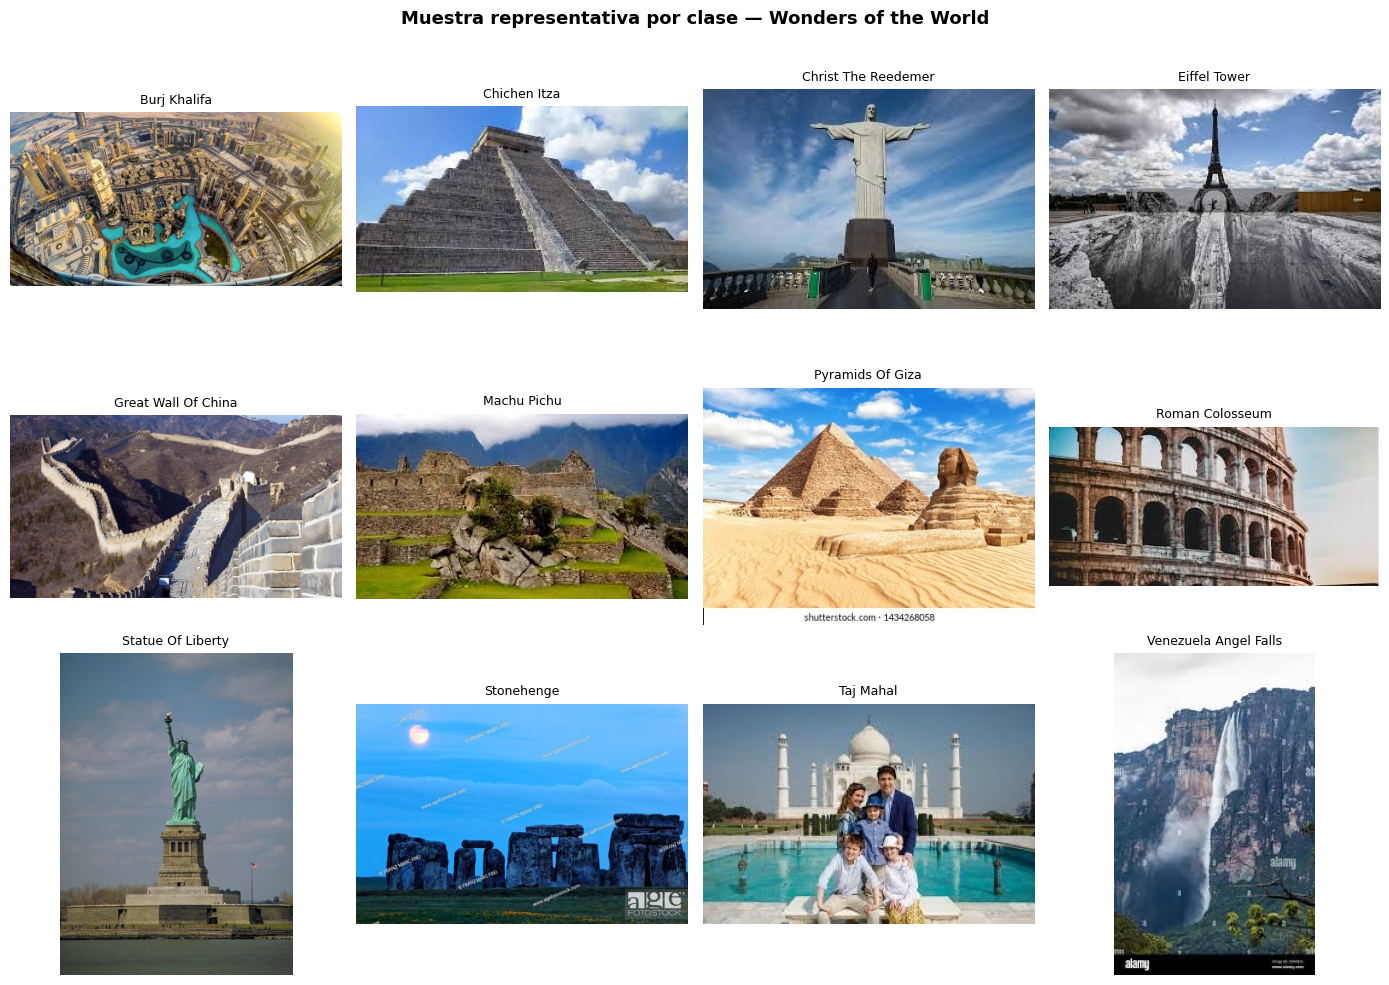

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, ejes = plt.subplots(3, 4, figsize=(14, 10))
ejes = ejes.flatten()

for i, clase in enumerate(CLASES):
    ruta_clase = os.path.join(DATA_ROOT, clase)
    imagenes   = [f for f in os.listdir(ruta_clase)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    muestra    = random.choice(imagenes)
    img        = mpimg.imread(os.path.join(ruta_clase, muestra))
    ejes[i].imshow(img)
    ejes[i].set_title(clase.replace("_", " ").title(), fontsize=9)
    ejes[i].axis("off")

for j in range(len(CLASES), len(ejes)):
    ejes[j].axis("off")

fig.suptitle("Muestra representativa por clase — Wonders of the World",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.8 Constantes globales del proyecto

In [8]:
NUM_CLASES  = len(CLASES)
CLASE_A_IDX = {clase: i for i, clase in enumerate(CLASES)}
IDX_A_CLASE = {i: clase for i, clase in enumerate(CLASES)}

IMG_ALTO    = 64
IMG_ANCHO   = 64
IMG_CANALES = 3
SEMILLA     = 42
BACKEND     = jax.default_backend()

print("Constantes globales del proyecto:")
print(f"  NUM_CLASES   : {NUM_CLASES}")
print(f"  IMG_ALTO     : {IMG_ALTO} px")
print(f"  IMG_ANCHO    : {IMG_ANCHO} px")
print(f"  IMG_CANALES  : {IMG_CANALES}")
print(f"  SEMILLA      : {SEMILLA}")
print(f"  BACKEND JAX  : {BACKEND}")
print()
print("Mapa clase → índice:")
for k, v in CLASE_A_IDX.items():
    print(f"  {v:2d} → {k}")


Constantes globales del proyecto:
  NUM_CLASES   : 12
  IMG_ALTO     : 64 px
  IMG_ANCHO    : 64 px
  IMG_CANALES  : 3
  SEMILLA      : 42
  BACKEND JAX  : gpu

Mapa clase → índice:
   0 → burj_khalifa
   1 → chichen_itza
   2 → christ_the_reedemer
   3 → eiffel_tower
   4 → great_wall_of_china
   5 → machu_pichu
   6 → pyramids_of_giza
   7 → roman_colosseum
   8 → statue_of_liberty
   9 → stonehenge
  10 → taj_mahal
  11 → venezuela_angel_falls


### 2.1 Importaciones del paso

In [9]:
import os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter

# Silenciar logs de TF (solo errores)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel("ERROR")

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"JAX backend : {jax.default_backend()}")


TensorFlow  : 2.20.0
NumPy       : 2.0.2
JAX backend : gpu


### 2.2 Recolección de rutas y etiquetas

Recorremos cada carpeta del dataset y construimos dos listas paralelas:
`rutas[]` con la ruta completa de cada imagen y `etiquetas[]` con su índice numérico de clase.

In [10]:
rutas     = []
etiquetas = []

for clase in CLASES:
    ruta_clase = os.path.join(DATA_ROOT, clase)
    for archivo in os.listdir(ruta_clase):
        if archivo.lower().endswith((".jpg", ".jpeg", ".png")):
            rutas.append(os.path.join(ruta_clase, archivo))
            etiquetas.append(CLASE_A_IDX[clase])

rutas     = np.array(rutas)
etiquetas = np.array(etiquetas, dtype=np.int32)

print(f"Total de imágenes recolectadas : {len(rutas)}")
print(f"Total de etiquetas             : {len(etiquetas)}")
print()
print("Distribución por clase:")
conteo = Counter(etiquetas)
for idx in sorted(conteo):
    print(f"  {idx:2d} | {IDX_A_CLASE[idx]:<30s} : {conteo[idx]:4d}")

Total de imágenes recolectadas : 3846
Total de etiquetas             : 3846

Distribución por clase:
   0 | burj_khalifa                   :  390
   1 | chichen_itza                   :  340
   2 | christ_the_reedemer            :  323
   3 | eiffel_tower                   :  391
   4 | great_wall_of_china            :  392
   5 | machu_pichu                    :  393
   6 | pyramids_of_giza               :  372
   7 | roman_colosseum                :  394
   8 | statue_of_liberty              :  238
   9 | stonehenge                     :  204
  10 | taj_mahal                      :  158
  11 | venezuela_angel_falls          :  251


### 2.3 División del dataset

| Conjunto | Porcentaje | Aprox. imágenes |
|----------|-----------|-----------------|
| Entrenamiento | 70 % | ~2,692 |
| Validación    | 15 % | ~577   |
| Prueba        | 15 % | ~577   |

Se usa `stratify=etiquetas` para mantener la proporción de clases en cada split.

In [11]:
# Primera división: 70% train — 30% temp
rutas_train, rutas_temp, etiq_train, etiq_temp = train_test_split(
    rutas, etiquetas,
    test_size=0.30,
    random_state=SEMILLA,
    stratify=etiquetas
)

# Segunda división: 50% val — 50% test del 30% temp → 15% cada uno
rutas_val, rutas_test, etiq_val, etiq_test = train_test_split(
    rutas_temp, etiq_temp,
    test_size=0.50,
    random_state=SEMILLA,
    stratify=etiq_temp
)

total = len(rutas)
print("División del dataset:")
print(f"  Entrenamiento : {len(rutas_train):5d} imágenes  ({len(rutas_train)/total*100:.1f}%)")
print(f"  Validación    : {len(rutas_val):5d} imágenes  ({len(rutas_val)/total*100:.1f}%)")
print(f"  Prueba        : {len(rutas_test):5d} imágenes  ({len(rutas_test)/total*100:.1f}%)")
print(f"  {'TOTAL':14s}: {total:5d} imágenes")

División del dataset:
  Entrenamiento :  2692 imágenes  (70.0%)
  Validación    :   577 imágenes  (15.0%)
  Prueba        :   577 imágenes  (15.0%)
  TOTAL         :  3846 imágenes


### 2.4 Funciones de carga y preprocesamiento

**Decisiones de preprocesamiento documentadas:**
- Redimensión a **64×64 px** — balance entre detalle visual y velocidad de entrenamiento en GPU
- Normalización a **[0, 1]** dividiendo entre 255 — estabiliza el gradiente descendente
- Canal **RGB** (3 canales) — se descartan imágenes en escala de grises convirtiéndolas a RGB
- Aumentación **solo en entrenamiento**: flip horizontal, brillo y contraste aleatorio — reduce sobreajuste

In [12]:
# ── Parámetros de imagen ─────────────────────────────────────────────────
ALTO   = IMG_ALTO    # 64
ANCHO  = IMG_ANCHO   # 64

def cargar_imagen(ruta):
    """Lee una imagen desde disco, la convierte a RGB y la redimensiona."""
    img = tf.io.read_file(ruta)
    img = tf.image.decode_jpeg(img, channels=3)      # fuerza 3 canales RGB
    img = tf.image.resize(img, [ALTO, ANCHO])        # redimensionar a 64×64
    img = tf.cast(img, tf.float32) / 255.0           # normalizar a [0, 1]
    return img

def aumentar(imagen):
    """Aumentación de datos aplicada SOLO al conjunto de entrenamiento."""
    imagen = tf.image.random_flip_left_right(imagen)           # flip horizontal
    imagen = tf.image.random_brightness(imagen, max_delta=0.15) # brillo aleatorio
    imagen = tf.image.random_contrast(imagen, lower=0.85, upper=1.15) # contraste
    imagen = tf.clip_by_value(imagen, 0.0, 1.0)               # mantener rango [0,1]
    return imagen

def procesar_train(ruta, etiqueta):
    """Pipeline de entrenamiento: carga + aumentación."""
    img = cargar_imagen(ruta)
    img = aumentar(img)
    return img, etiqueta

def procesar_eval(ruta, etiqueta):
    """Pipeline de validación/prueba: solo carga, sin aumentación."""
    img = cargar_imagen(ruta)
    return img, etiqueta

print("Funciones de preprocesamiento definidas:")
print("  cargar_imagen()  → lee, redimensiona 64×64, normaliza [0,1]")
print("  aumentar()       → flip, brillo±15%, contraste 85-115%")
print("  procesar_train() → carga + aumentación  (solo entrenamiento)")
print("  procesar_eval()  → solo carga           (validación y prueba)")


Funciones de preprocesamiento definidas:
  cargar_imagen()  → lee, redimensiona 64×64, normaliza [0,1]
  aumentar()       → flip, brillo±15%, contraste 85-115%
  procesar_train() → carga + aumentación  (solo entrenamiento)
  procesar_eval()  → solo carga           (validación y prueba)


### 2.5 Construcción de pipelines `tf.data`

`tf.data` permite cargar imágenes de forma **paralela y prefetcheada**,
evitando que la CPU sea el cuello de botella mientras la GPU procesa el lote anterior.


In [13]:
BATCH_SIZE  = 32          # tamaño de lote base (se variará en experimentos)
AUTOTUNE    = tf.data.AUTOTUNE

def construir_pipeline(rutas, etiquetas, batch_size,
                        entrenamiento=False, mezclar=True):
    """
    Construye un pipeline tf.data optimizado para GPU.

    Parámetros
    ----------
    rutas        : array de rutas de imágenes
    etiquetas    : array de etiquetas numéricas
    batch_size   : tamaño del lote
    entrenamiento: si True aplica aumentación de datos
    mezclar      : si True mezcla el dataset en cada época
    """
    ds = tf.data.Dataset.from_tensor_slices((rutas, etiquetas))

    if mezclar:
        ds = ds.shuffle(buffer_size=len(rutas), seed=SEMILLA,
                        reshuffle_each_iteration=True)

    # Aplicar preprocesamiento en paralelo
    fn = procesar_train if entrenamiento else procesar_eval
    ds = ds.map(fn, num_parallel_calls=AUTOTUNE)

    # Agrupar en lotes y prefetch para la GPU
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)

    return ds


# Construir los tres pipelines
ds_train = construir_pipeline(rutas_train, etiq_train,
                               BATCH_SIZE, entrenamiento=True)
ds_val   = construir_pipeline(rutas_val,   etiq_val,
                               BATCH_SIZE, entrenamiento=False)
ds_test  = construir_pipeline(rutas_test,  etiq_test,
                               BATCH_SIZE, entrenamiento=False)

# Información de los pipelines
n_train = len(rutas_train)
n_val   = len(rutas_val)
n_test  = len(rutas_test)

print("Pipelines tf.data construidos:")
print(f"  ds_train : {n_train} imágenes → {n_train // BATCH_SIZE + 1} lotes de {BATCH_SIZE}")
print(f"  ds_val   : {n_val}  imágenes → {n_val  // BATCH_SIZE + 1} lotes de {BATCH_SIZE}")
print(f"  ds_test  : {n_test}  imágenes → {n_test  // BATCH_SIZE + 1} lotes de {BATCH_SIZE}")
print()
print("Configuración:")
print(f"  batch_size     : {BATCH_SIZE}")
print(f"  prefetch       : AUTOTUNE")
print(f"  num_parallel   : AUTOTUNE")
print(f"  shuffle train  : True (reshuffle cada época)")


Pipelines tf.data construidos:
  ds_train : 2692 imágenes → 85 lotes de 32
  ds_val   : 577  imágenes → 19 lotes de 32
  ds_test  : 577  imágenes → 19 lotes de 32

Configuración:
  batch_size     : 32
  prefetch       : AUTOTUNE
  num_parallel   : AUTOTUNE
  shuffle train  : True (reshuffle cada época)


### lote

In [14]:
# Extraer un lote de entrenamiento y verificar dimensiones y valores
for imagenes_lote, etiquetas_lote in ds_train.take(1):
    imgs = imagenes_lote.numpy()
    etiq = etiquetas_lote.numpy()

print("Verificación del primer lote de entrenamiento:")
print(f"  Forma del lote    : {imgs.shape}")
print(f"  Tipo de dato      : {imgs.dtype}")
print(f"  Valor mínimo      : {imgs.min():.4f}  (esperado ≥ 0.0)")
print(f"  Valor máximo      : {imgs.max():.4f}  (esperado ≤ 1.0)")
print(f"  Valor medio       : {imgs.mean():.4f}")
print(f"  Etiquetas en lote : {sorted(set(etiq.tolist()))}")
print()
print(f"  ✓ Shape correcto  : {imgs.shape == (BATCH_SIZE, ALTO, ANCHO, 3)}")
print(f"  ✓ Rango correcto  : {0.0 <= imgs.min() and imgs.max() <= 1.0}")


Verificación del primer lote de entrenamiento:
  Forma del lote    : (32, 64, 64, 3)
  Tipo de dato      : float32
  Valor mínimo      : 0.0000  (esperado ≥ 0.0)
  Valor máximo      : 1.0000  (esperado ≤ 1.0)
  Valor medio       : 0.4677
  Etiquetas en lote : [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]

  ✓ Shape correcto  : True
  ✓ Rango correcto  : True


### 2.7 Visualización de imágenes preprocesadas y aumentadas

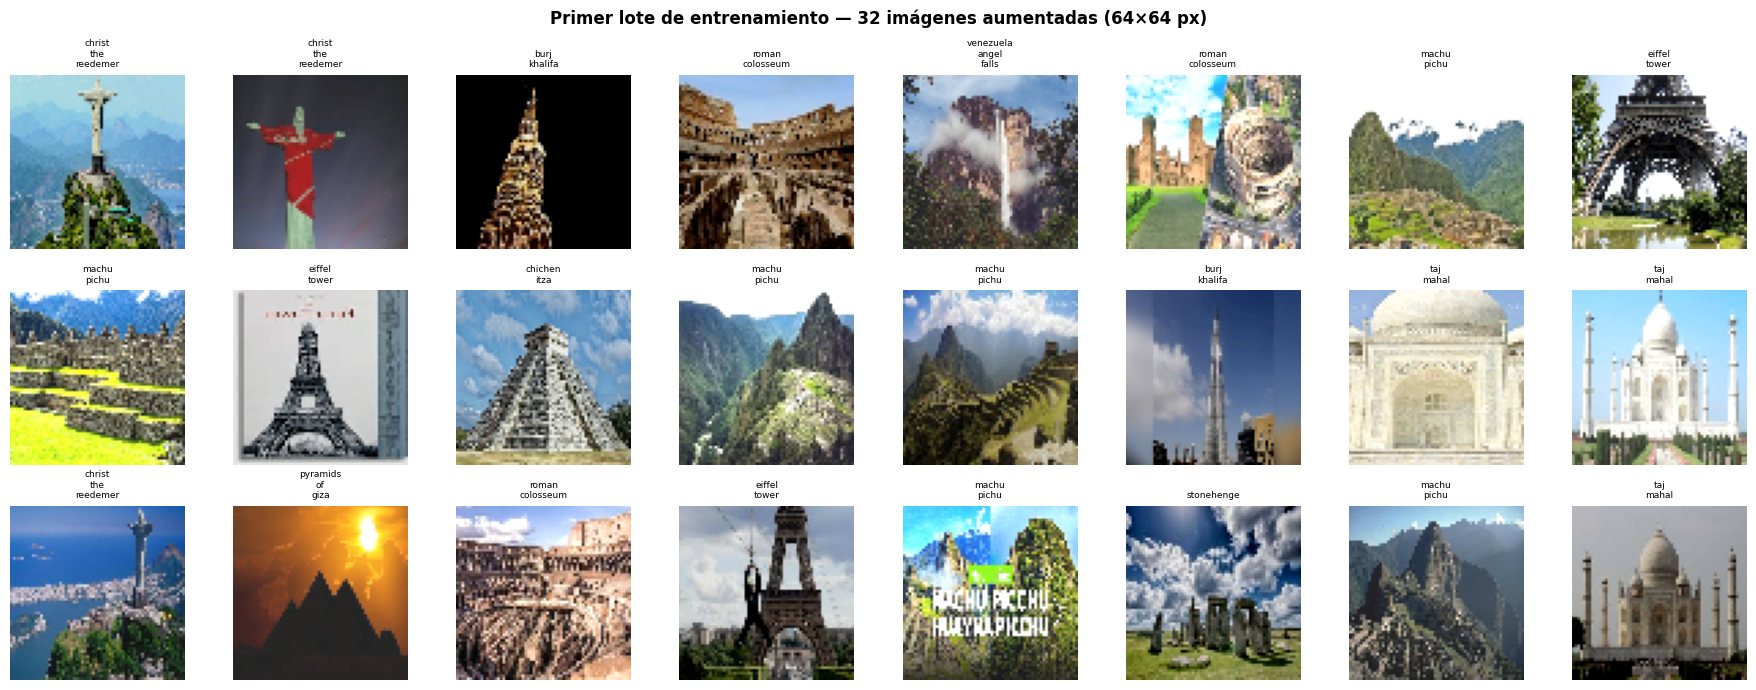

In [15]:
fig, ejes = plt.subplots(3, 8, figsize=(18, 7))
ejes = ejes.flatten()

for i in range(24):
    ejes[i].imshow(imgs[i])
    ejes[i].set_title(IDX_A_CLASE[etiq[i]].replace("_", "\n"),
                      fontsize=6.5)
    ejes[i].axis("off")

fig.suptitle(
    f"Primer lote de entrenamiento — {BATCH_SIZE} imágenes aumentadas (64×64 px)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


### 2.8 Distribución de clases por conjunto

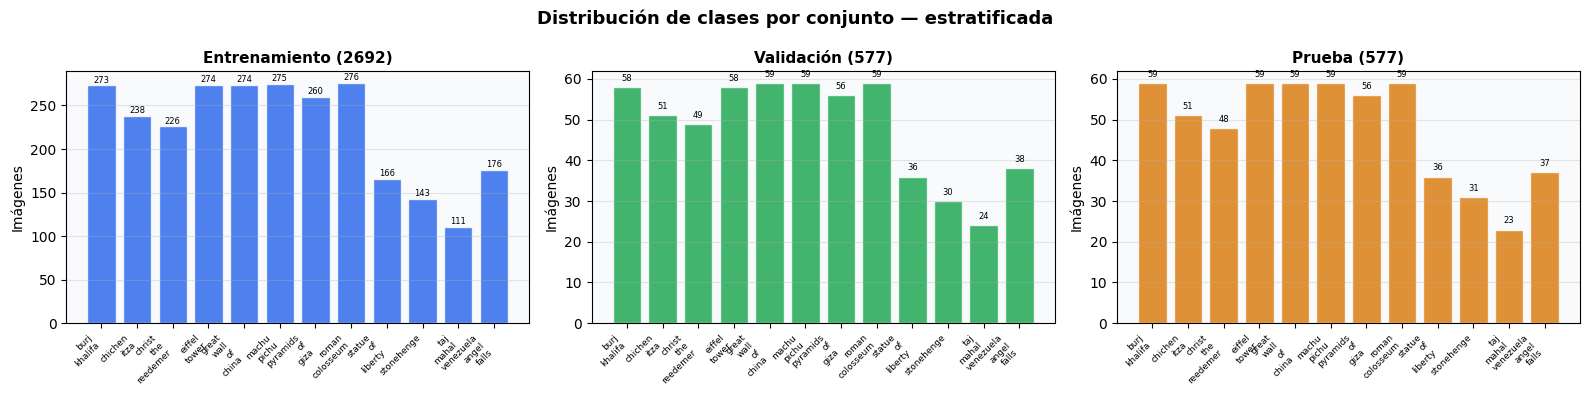

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
nombres_clases = [IDX_A_CLASE[i].replace("_", "\n") for i in range(NUM_CLASES)]

for ax, (etiq_set, titulo, color) in zip(ejes, [
    (etiq_train, f"Entrenamiento ({len(etiq_train)})", "#2563EB"),
    (etiq_val,   f"Validación ({len(etiq_val)})",      "#16A34A"),
    (etiq_test,  f"Prueba ({len(etiq_test)})",          "#D97706"),
]):
    conteos = [np.sum(etiq_set == i) for i in range(NUM_CLASES)]
    barras  = ax.bar(range(NUM_CLASES), conteos, color=color, alpha=0.8, edgecolor="white")
    ax.set_xticks(range(NUM_CLASES))
    ax.set_xticklabels(nombres_clases, fontsize=6.5, rotation=45, ha="right")
    ax.set_ylabel("Imágenes")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.set_facecolor("#F8FAFC")
    for barra, cnt in zip(barras, conteos):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
                str(cnt), ha="center", va="bottom", fontsize=6)

fig.suptitle("Distribución de clases por conjunto — estratificada",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.9 Resumen de decisiones de preprocesamiento

In [18]:
print("=" * 55)
print("  Resumen — Preprocesamiento del Dataset")
print(f"  Resolución de entrada  : {ALTO}×{ANCHO} px  (3 canales RGB)")
print(f"  Normalización          : píxeles / 255  → [0.0, 1.0]")
print(f"  Aumentación (train)    : flip H · brillo±15% · contraste±15%")
print(f"  Split                  : 70% / 15% / 15%  (estratificado)")
print(f"  Tamaño de lote base    : {BATCH_SIZE}")
print(f"  Pipeline               : tf.data  (paralelo + prefetch AUTOTUNE)")
print()
print(f"  Conjunto entrenamiento : {len(rutas_train):5d} imágenes")
print(f"  Conjunto validación    : {len(rutas_val):5d} imágenes")
print(f"  Conjunto prueba        : {len(rutas_test):5d} imágenes")
print(f"  Total                  : {len(rutas):5d} imágenes")
print("=" * 55)
print()
print("  Paso 2 completado — listos para construir el modelo.")


  Resumen — Preprocesamiento del Dataset
  Resolución de entrada  : 64×64 px  (3 canales RGB)
  Normalización          : píxeles / 255  → [0.0, 1.0]
  Aumentación (train)    : flip H · brillo±15% · contraste±15%
  Split                  : 70% / 15% / 15%  (estratificado)
  Tamaño de lote base    : 32
  Pipeline               : tf.data  (paralelo + prefetch AUTOTUNE)

  Conjunto entrenamiento :  2692 imágenes
  Conjunto validación    :   577 imágenes
  Conjunto prueba        :   577 imágenes
  Total                  :  3846 imágenes

  Paso 2 completado — listos para construir el modelo.


### 3.1 Importaciones

In [20]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt
import time
import flax # Import the main flax package
from flax import nnx
from functools import partial

print(f"JAX     : {jax.__version__}  —  backend: {jax.default_backend()}")
print(f"Flax    : {flax.__version__}") # Access flax.__version__ directly
print(f"Optax   : {optax.__version__}")

JAX     : 0.10.1  —  backend: gpu
Flax    : 0.12.7
Optax   : 0.2.8


### 3.2 Arquitectura CNN — Flax NNX

La arquitectura implementada extiende el mínimo requerido por el PDF:

```
Entrada (64×64×3)
    │
    ├─ Conv(32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    ├─ Conv(64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    ├─ Conv(128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    │
    ├─ Flatten
    ├─ Dense(256) → ReLU → Dropout(0.4)
    └─ Dense(12)  → Salida (logits)
```

**Justificación de decisiones:**
- **3 bloques conv** en lugar de 2: el dataset tiene 12 clases con alta variabilidad visual
- **BatchNorm** en cada bloque: estabiliza el entrenamiento y actúa como regularizador
- **Dropout(0.4)** antes de la capa final: reduce sobreajuste dado el tamaño moderado del dataset
- **Logits sin softmax** en la salida: `optax.softmax_cross_entropy_with_integer_labels` lo aplica internamente

In [21]:
class CNN(nnx.Module):
    """
    Red neuronal convolucional para clasificación de imágenes.

    Arquitectura:
        3 bloques Conv → BatchNorm → ReLU → MaxPool
        Flatten → Dense(256) → Dropout → Dense(num_clases)

    Parámetros
    ----------
    num_clases : int   – número de categorías de salida
    filtros    : int   – filtros del primer bloque (se duplican en cada bloque)
    neuronas   : int   – neuronas de la capa densa oculta
    tasa_drop  : float – tasa de dropout (0.0 = desactivado)
    rngs       : nnx.Rngs – generadores de números aleatorios de JAX/Flax
    """

    def __init__(self, num_clases, filtros=32, neuronas=256,
                 tasa_drop=0.4, rngs=nnx.Rngs(0)):

        # ── Bloque 1: Conv(filtros) ──────────────────────────────────────
        self.conv1 = nnx.Conv(
            in_features=3, out_features=filtros,
            kernel_size=(3, 3), padding="SAME", rngs=rngs
        )
        self.bn1 = nnx.BatchNorm(num_features=filtros, rngs=rngs)

        # ── Bloque 2: Conv(filtros*2) ────────────────────────────────────
        self.conv2 = nnx.Conv(
            in_features=filtros, out_features=filtros * 2,
            kernel_size=(3, 3), padding="SAME", rngs=rngs
        )
        self.bn2 = nnx.BatchNorm(num_features=filtros * 2, rngs=rngs)

        # ── Bloque 3: Conv(filtros*4) ────────────────────────────────────
        self.conv3 = nnx.Conv(
            in_features=filtros * 2, out_features=filtros * 4,
            kernel_size=(3, 3), padding="SAME", rngs=rngs
        )
        self.bn3 = nnx.BatchNorm(num_features=filtros * 4, rngs=rngs)

        # ── Capas densas ─────────────────────────────────────────────────
        # Después de 3 MaxPool(2×2) sobre imagen 64×64:
        # 64 → 32 → 16 → 8  →  8 * 8 * (filtros*4) neuronas
        dim_flat = 8 * 8 * (filtros * 4)
        self.dense1  = nnx.Linear(dim_flat, neuronas, rngs=rngs)
        self.dropout = nnx.Dropout(rate=tasa_drop, rngs=rngs)
        self.dense2  = nnx.Linear(neuronas, num_clases, rngs=rngs)

    def __call__(self, x, entrenamiento=False):
        """
        Propagación hacia adelante.

        Parámetros
        ----------
        x             : array (batch, alto, ancho, canales)
        entrenamiento : bool – activa BatchNorm y Dropout en modo entrenamiento
        """
        # Bloque 1
        x = self.conv1(x)
        x = self.bn1(x, use_running_average=not entrenamiento)
        x = jax.nn.relu(x)
        x = jax.lax.reduce_window(
            x, -jnp.inf, jax.lax.max,
            window_dimensions=(1, 2, 2, 1),
            window_strides=(1, 2, 2, 1),
            padding="VALID"
        )

        # Bloque 2
        x = self.conv2(x)
        x = self.bn2(x, use_running_average=not entrenamiento)
        x = jax.nn.relu(x)
        x = jax.lax.reduce_window(
            x, -jnp.inf, jax.lax.max,
            window_dimensions=(1, 2, 2, 1),
            window_strides=(1, 2, 2, 1),
            padding="VALID"
        )

        # Bloque 3
        x = self.conv3(x)
        x = self.bn3(x, use_running_average=not entrenamiento)
        x = jax.nn.relu(x)
        x = jax.lax.reduce_window(
            x, -jnp.inf, jax.lax.max,
            window_dimensions=(1, 2, 2, 1),
            window_strides=(1, 2, 2, 1),
            padding="VALID"
        )

        # Clasificador
        x = x.reshape((x.shape[0], -1))           # Flatten
        x = self.dense1(x)
        x = jax.nn.relu(x)
        x = self.dropout(x, deterministic=not entrenamiento)
        x = self.dense2(x)                         # logits (sin softmax)
        return x


# Instanciar modelo con hiperparámetros base
modelo = CNN(
    num_clases=NUM_CLASES,
    filtros=32,
    neuronas=256,
    tasa_drop=0.4,
    rngs=nnx.Rngs(SEMILLA)
)

# Contar parámetros
grafo, estado = nnx.split(modelo)
total_params = sum(x.size for x in jax.tree_util.tree_leaves(estado))
print(f"Modelo CNN instanciado correctamente.")
print(f"Total de parámetros : {total_params:,}")
print()

# Prueba de forma con un lote ficticio
x_prueba = jnp.ones((4, IMG_ALTO, IMG_ANCHO, IMG_CANALES))
logits   = modelo(x_prueba, entrenamiento=False)
print(f"Prueba de forma:")
print(f"  Entrada  : {x_prueba.shape}")
print(f"  Salida   : {logits.shape}  (esperado: (4, {NUM_CLASES}))")


Modelo CNN instanciado correctamente.
Total de parámetros : 2,194,638

Prueba de forma:
  Entrada  : (4, 64, 64, 3)
  Salida   : (4, 12)  (esperado: (4, 12))


### 3.3 Función de pérdida y métricas

In [22]:
def perdida_fn(modelo, imagenes, etiquetas):
    """
    Calcula la pérdida de entropía cruzada categórica.
    optax aplica softmax internamente — el modelo retorna logits.
    """
    logits = modelo(imagenes, entrenamiento=True)
    perdida = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=etiquetas
    ).mean()
    return perdida, logits


def calcular_exactitud(logits, etiquetas):
    """Calcula la exactitud (accuracy) dado logits y etiquetas reales."""
    predicciones = jnp.argmax(logits, axis=-1)
    return jnp.mean(predicciones == etiquetas)


print("Función de pérdida  : softmax_cross_entropy_with_integer_labels")
print("Métrica principal   : exactitud (accuracy)")


Función de pérdida  : softmax_cross_entropy_with_integer_labels
Métrica principal   : exactitud (accuracy)


### 3.4 Optimizador y paso de entrenamiento compilado con `jax.jit`

In [24]:
# ── Hiperparámetros base ─────────────────────────────────────────────────
LEARNING_RATE = 1e-3
EPOCAS        = 20

# Optimizador Adam con decaimiento coseno del learning rate
scheduler = optax.cosine_decay_schedule(
    init_value=LEARNING_RATE,
    decay_steps=EPOCAS * 85          # 85 lotes por época aprox.
)
# Use nnx.ModelAndOptimizer as suggested by the error message
optimizador = nnx.ModelAndOptimizer(modelo, optax.adam(scheduler))


@nnx.jit                              # compilación JIT de JAX/Flax
def paso_entrenamiento(modelo, optimizador, imagenes, etiquetas):
    """
    Ejecuta un paso de entrenamiento completo:
    1. Forward pass con diferenciación automática
    2. Cálculo de gradientes
    3. Actualización de parámetros con el optimizador
    """
    grad_fn = nnx.value_and_grad(perdida_fn, has_aux=True)
    (perdida, logits), gradientes = grad_fn(modelo, imagenes, etiquetas)
    optimizador.update(gradientes)
    exactitud = calcular_exactitud(logits, etiquetas)
    return perdida, exactitud


@nnx.jit
def paso_evaluacion(modelo, imagenes, etiquetas):
    """Ejecuta un paso de evaluación sin actualizar parámetros."""
    logits    = modelo(imagenes, entrenamiento=False)
    perdida   = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=etiquetas
    ).mean()
    exactitud = calcular_exactitud(logits, etiquetas)
    return perdida, exactitud


print("Optimizador  : Adam con cosine decay schedule")
print(f"  LR inicial : {LEARNING_RATE}")
print(f"  Épocas     : {EPOCAS}")
print("Compilación  : @nnx.jit  (paso entrenamiento + evaluación)")

Optimizador  : Adam con cosine decay schedule
  LR inicial : 0.001
  Épocas     : 20
Compilación  : @nnx.jit  (paso entrenamiento + evaluación)


### 3.5 Ciclo completo de entrenamiento

In [25]:
def entrenar(modelo, optimizador, ds_train, ds_val, epocas,
             nombre_exp="base"):
    """
    Ciclo completo de entrenamiento con registro de métricas por época.

    Retorna un diccionario con el historial de entrenamiento.
    """
    historial = {
        "perdida_train": [], "exactitud_train": [],
        "perdida_val":   [], "exactitud_val":   [],
        "tiempo_epoca":  []
    }

    t_inicio_total = time.time()
    print(f"{'Época':>6} {'P.Train':>9} {'Acc.Train':>10} "
          f"{'P.Val':>8} {'Acc.Val':>9} {'Tiempo':>8}")
    print("-" * 58)

    for epoca in range(1, epocas + 1):
        t0 = time.time()

        # ── Entrenamiento ───────────────────────────────────────────────
        perdidas_t, exactitudes_t = [], []
        for imagenes_tf, etiq_tf in ds_train:
            imgs = jnp.array(imagenes_tf.numpy())
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_entrenamiento(modelo, optimizador, imgs, etiq)
            perdidas_t.append(float(p))
            exactitudes_t.append(float(a))

        # ── Validación ──────────────────────────────────────────────────
        perdidas_v, exactitudes_v = [], []
        for imagenes_tf, etiq_tf in ds_val:
            imgs = jnp.array(imagenes_tf.numpy())
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_evaluacion(modelo, imgs, etiq)
            perdidas_v.append(float(p))
            exactitudes_v.append(float(a))

        t_epoca = time.time() - t0

        # Promedios de la época
        pt = np.mean(perdidas_t);   at = np.mean(exactitudes_t)
        pv = np.mean(perdidas_v);   av = np.mean(exactitudes_v)

        historial["perdida_train"].append(pt)
        historial["exactitud_train"].append(at)
        historial["perdida_val"].append(pv)
        historial["exactitud_val"].append(av)
        historial["tiempo_epoca"].append(t_epoca)

        print(f"{epoca:>6d} {pt:>9.4f} {at*100:>9.2f}% "
              f"{pv:>8.4f} {av*100:>8.2f}% {t_epoca:>7.1f}s")

    t_total = time.time() - t_inicio_total
    historial["tiempo_total"]    = t_total
    historial["t_media_epoca"]   = np.mean(historial["tiempo_epoca"])
    historial["exactitud_final_train"] = historial["exactitud_train"][-1]
    historial["exactitud_final_val"]   = historial["exactitud_val"][-1]

    print("-" * 58)
    print(f"Tiempo total        : {t_total:.1f} s")
    print(f"Tiempo medio/época  : {historial['t_media_epoca']:.1f} s")
    print(f"Exactitud train     : {historial['exactitud_final_train']*100:.2f}%")
    print(f"Exactitud val       : {historial['exactitud_final_val']*100:.2f}%")

    return historial


# ── Ejecutar entrenamiento base ──────────────────────────────────────────
print(f"Iniciando entrenamiento — {EPOCAS} épocas")
print(f"Configuración: LR={LEARNING_RATE}, batch={BATCH_SIZE}, "
      f"filtros=32, neuronas=256\n")

historial_base = entrenar(modelo, optimizador, ds_train, ds_val, EPOCAS)


Iniciando entrenamiento — 20 épocas
Configuración: LR=0.001, batch=32, filtros=32, neuronas=256

 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
----------------------------------------------------------
     1    2.7425     21.43%   2.2518    22.04%    48.3s
     2    2.0160     31.43%   2.1700    25.00%     7.1s
     3    1.8474     35.37%   2.1648    24.67%    11.5s
     4    1.7205     39.60%   1.8942    39.64%     9.6s
     5    1.6625     43.57%   1.6931    42.93%     8.3s
     6    1.5768     45.44%   1.6791    41.61%     7.3s
     7    1.4664     49.26%   1.2638    60.53%    11.5s
     8    1.3635     53.01%   1.2076    65.95%     9.7s
     9    1.3124     54.52%   1.1661    60.86%    11.5s
    10    1.2463     55.22%   1.0868    70.39%     7.4s
    11    1.1567     58.53%   1.2379    64.14%    12.2s
    12    1.1001     60.77%   0.9687    67.43%    18.6s
    13    1.0491     63.05%   0.9746    74.18%    11.5s
    14    0.9963     64.60%   1.0400    68.42%    11.6s
    

### 3.6 Evaluación final en el conjunto de prueba

In [26]:
perdidas_test, exactitudes_test = [], []
for imagenes_tf, etiq_tf in ds_test:
    imgs = jnp.array(imagenes_tf.numpy())
    etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
    p, a = paso_evaluacion(modelo, imgs, etiq)
    perdidas_test.append(float(p))
    exactitudes_test.append(float(a))

perdida_test   = np.mean(perdidas_test)
exactitud_test = np.mean(exactitudes_test)

print("=" * 45)
print("  Evaluación final — Conjunto de Prueba")
print("=" * 45)
print(f"  Pérdida   : {perdida_test:.4f}")
print(f"  Exactitud : {exactitud_test*100:.2f}%")
print("=" * 45)


  Evaluación final — Conjunto de Prueba
  Pérdida   : 0.8325
  Exactitud : 70.23%


### 3.7 Curvas de pérdida y exactitud

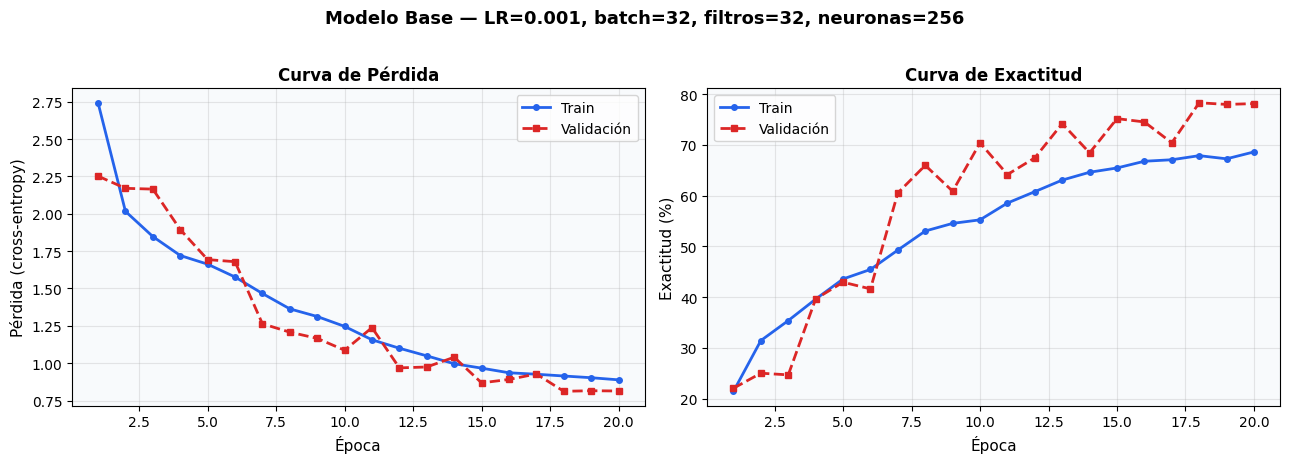

In [27]:
def graficar_historial(historial, titulo="Entrenamiento base"):
    epocas_eje = range(1, len(historial["perdida_train"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor("white")

    # ── Pérdida ──────────────────────────────────────────────────────────
    ax1.plot(epocas_eje, historial["perdida_train"],
             "o-", color="#2563EB", lw=2, ms=4, label="Train")
    ax1.plot(epocas_eje, historial["perdida_val"],
             "s--", color="#DC2626", lw=2, ms=4, label="Validación")
    ax1.set_xlabel("Época", fontsize=11)
    ax1.set_ylabel("Pérdida (cross-entropy)", fontsize=11)
    ax1.set_title("Curva de Pérdida", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor("#F8FAFC")

    # ── Exactitud ────────────────────────────────────────────────────────
    ax2.plot(epocas_eje, [v*100 for v in historial["exactitud_train"]],
             "o-", color="#2563EB", lw=2, ms=4, label="Train")
    ax2.plot(epocas_eje, [v*100 for v in historial["exactitud_val"]],
             "s--", color="#DC2626", lw=2, ms=4, label="Validación")
    ax2.set_xlabel("Época", fontsize=11)
    ax2.set_ylabel("Exactitud (%)", fontsize=11)
    ax2.set_title("Curva de Exactitud", fontsize=12, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor("#F8FAFC")

    fig.suptitle(titulo, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


graficar_historial(historial_base,
    titulo=f"Modelo Base — LR={LEARNING_RATE}, batch={BATCH_SIZE}, "
           f"filtros=32, neuronas=256")


### 3.8 Resumen del entrenamiento base

In [28]:
throughput = len(rutas_train) / historial_base["t_media_epoca"]

print("=" * 52)
print("  Resumen — Entrenamiento Base")
print("=" * 52)
print(f"  Arquitectura      : CNN 3 bloques conv + 2 dense")
print(f"  Filtros           : 32 → 64 → 128")
print(f"  Neuronas dense    : 256")
print(f"  Dropout           : 0.4")
print(f"  Optimizador       : Adam + cosine decay")
print(f"  Learning rate     : {LEARNING_RATE}")
print(f"  Épocas            : {EPOCAS}")
print(f"  Batch size        : {BATCH_SIZE}")
print()
print(f"  Tiempo total      : {historial_base['tiempo_total']:.1f} s")
print(f"  Tiempo/época      : {historial_base['t_media_epoca']:.1f} s")
print(f"  Throughput        : {throughput:.0f} imágenes/s")
print()
print(f"  Exactitud train   : {historial_base['exactitud_final_train']*100:.2f}%")
print(f"  Exactitud val     : {historial_base['exactitud_final_val']*100:.2f}%")
print(f"  Exactitud prueba  : {exactitud_test*100:.2f}%")
print("=" * 52)
print()
print("  Paso 3 completado — listo para experimentos.")


  Resumen — Entrenamiento Base
  Arquitectura      : CNN 3 bloques conv + 2 dense
  Filtros           : 32 → 64 → 128
  Neuronas dense    : 256
  Dropout           : 0.4
  Optimizador       : Adam + cosine decay
  Learning rate     : 0.001
  Épocas            : 20
  Batch size        : 32

  Tiempo total      : 239.2 s
  Tiempo/época      : 12.0 s
  Throughput        : 225 imágenes/s

  Exactitud train   : 68.60%
  Exactitud val     : 78.12%
  Exactitud prueba  : 70.23%

  Paso 3 completado — listo para experimentos.


## Paso 4: Experimentos

In [31]:
def ejecutar_experimento(config, epocas=15):
    """
    Crea un modelo y optimizador frescos con la configuración dada,
    entrena y retorna el historial.

    Parámetros
    ----------
    config : dict con claves:
        filtros, neuronas, lr, batch_size, nombre
    epocas : int — épocas de entrenamiento
    """
    # Reconstruir pipelines con el batch_size del experimento
    bs = config["batch_size"]
    ds_tr = construir_pipeline(rutas_train, etiq_train, bs,
                               entrenamiento=True)
    ds_vl = construir_pipeline(rutas_val,   etiq_val,   bs,
                               entrenamiento=False)

    # Modelo fresco con la configuración indicada
    modelo_exp = CNN(
        num_clases=NUM_CLASES,
        filtros=config["filtros"],
        neuronas=config["neuronas"],
        tasa_drop=0.4,
        rngs=nnx.Rngs(SEMILLA)
    )

    # Optimizador con el LR indicado
    sched = optax.cosine_decay_schedule(
        init_value=config["lr"],
        decay_steps=epocas * (len(rutas_train) // bs + 1)
    )
    opt_exp = nnx.ModelAndOptimizer(modelo_exp, optax.adam(sched))

    print(f"\n{'='*55}")
    print(f"  Experimento: {config['nombre']}")
    print(f"{'='*55}")

    hist = entrenar(modelo_exp, opt_exp, ds_tr, ds_vl, epocas)

    # Exactitud en prueba
    p_test, a_test = [], []
    ds_tst = construir_pipeline(rutas_test, etiq_test, bs,
                                entrenamiento=False)
    for imgs_tf, etiq_tf in ds_tst:
        imgs = jnp.array(imgs_tf.numpy())
        etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
        p, a = paso_evaluacion(modelo_exp, imgs, etiq)
        p_test.append(float(p)); a_test.append(float(a))

    hist["exactitud_prueba"] = float(np.mean(a_test))
    hist["perdida_prueba"]   = float(np.mean(p_test))
    hist["config"]           = config
    hist["throughput"]       = len(rutas_train) / hist["t_media_epoca"]

    print(f"  Exactitud prueba : {hist['exactitud_prueba']*100:.2f}%")
    return hist, modelo_exp


EPOCAS_EXP = 15   # épocas por experimento (menos que el base para ahorrar tiempo)
print(f"Función ejecutar_experimento() lista — {EPOCAS_EXP} épocas por experimento")

Función ejecutar_experimento() lista — 15 épocas por experimento


### 6.1 Experimento: Impacto del Tamaño de Lote

Se mantienen fijos: LR=1e-3, filtros=32, neuronas=256  
Se varía: **batch_size ∈ {32, 64, 128}**

In [32]:
resultados_batch = {}

configs_batch = [
    {"nombre": "batch=32",  "batch_size": 32,  "lr": 1e-3, "filtros": 32, "neuronas": 256},
    {"nombre": "batch=64",  "batch_size": 64,  "lr": 1e-3, "filtros": 32, "neuronas": 256},
    {"nombre": "batch=128", "batch_size": 128, "lr": 1e-3, "filtros": 32, "neuronas": 256},
]

for cfg in configs_batch:
    hist, _ = ejecutar_experimento(cfg, epocas=EPOCAS_EXP)
    resultados_batch[cfg["nombre"]] = hist



  Experimento: batch=32
 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
----------------------------------------------------------
     1    2.4639     28.46%   2.1772    30.10%    15.7s
     2    1.8390     36.40%   2.2431    21.55%     7.4s
     3    1.7367     39.71%   1.9082    33.72%     9.6s
     4    1.6035     45.07%   1.6866    42.27%     8.0s
     5    1.5178     48.49%   1.5424    51.15%     7.6s
     6    1.4235     49.63%   1.2578    61.68%    10.0s
     7    1.3363     53.71%   1.3181    61.35%     7.8s
     8    1.2764     55.22%   1.0926    67.93%     7.8s
     9    1.1140     61.51%   1.0296    72.20%     8.3s
    10    1.0803     63.05%   0.9859    67.11%     7.2s
    11    1.0031     64.19%   0.9610    68.75%     9.5s
    12    0.9423     67.76%   0.8651    74.51%     8.3s
    13    0.9174     69.08%   0.8965    72.20%    12.8s
    14    0.8991     69.41%   0.9339    72.04%    12.8s
    15    0.8798     69.34%   0.8171    76.97%     8.3s
--------------------

In [33]:
# ── Tabla comparativa batch ───────────────────────────────────────────────
print(f"{'Config':<12} {'T.Total(s)':>10} {'T/época(s)':>11} "
      f"{'Acc.Val':>9} {'Acc.Test':>9} {'Throughput':>12}")
print("-" * 66)
for nombre, h in resultados_batch.items():
    print(f"{nombre:<12} {h['tiempo_total']:>10.1f} {h['t_media_epoca']:>11.1f} "
          f"{h['exactitud_final_val']*100:>8.2f}% "
          f"{h['exactitud_prueba']*100:>8.2f}% "
          f"{h['throughput']:>10.0f} img/s")


Config       T.Total(s)  T/época(s)   Acc.Val  Acc.Test   Throughput
------------------------------------------------------------------
batch=32          141.0         9.4    76.97%    70.72%        286 img/s
batch=64          143.3         9.6    71.41%    60.00%        282 img/s
batch=128         163.5        10.9    54.05%    48.76%        247 img/s


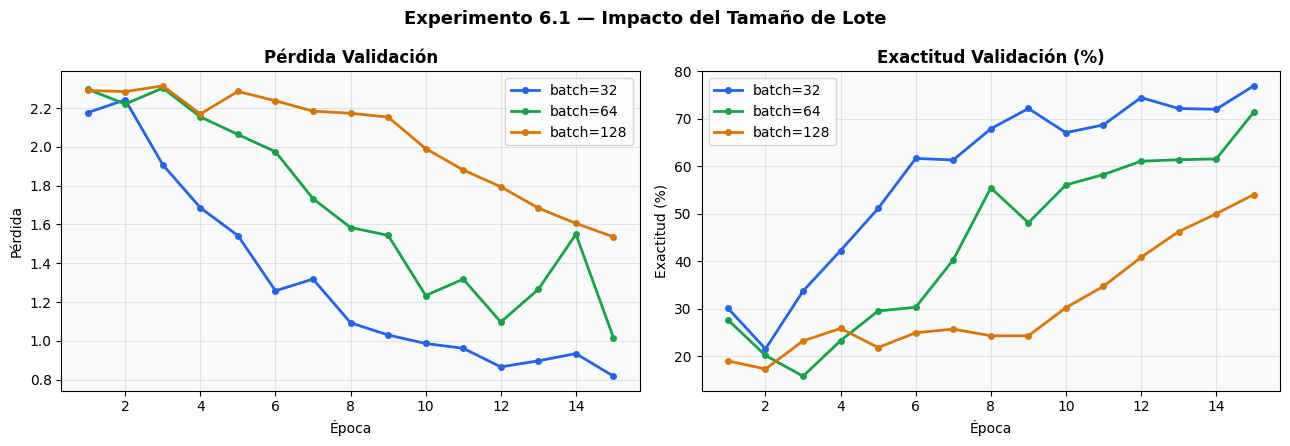

In [34]:
# ── Gráfica batch ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores = {"batch=32": "#2563EB", "batch=64": "#16A34A", "batch=128": "#D97706"}

for nombre, h in resultados_batch.items():
    ep = range(1, len(h["perdida_val"]) + 1)
    axes[0].plot(ep, h["perdida_val"],   "o-", color=colores[nombre],
                 lw=2, ms=4, label=nombre)
    axes[1].plot(ep, [v*100 for v in h["exactitud_val"]], "o-",
                 color=colores[nombre], lw=2, ms=4, label=nombre)

for ax, titulo, ylabel in zip(axes,
    ["Pérdida Validación", "Exactitud Validación (%)"],
    ["Pérdida", "Exactitud (%)"]):
    ax.set_xlabel("Época"); ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_facecolor("#F8FAFC")

fig.suptitle("Experimento 6.1 — Impacto del Tamaño de Lote",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 6.2 Experimento: Impacto de la Tasa de Aprendizaje

Se mantienen fijos: batch=32, filtros=32, neuronas=256  
Se varía: **lr ∈ {1e-2, 1e-3, 1e-4}**

In [35]:
resultados_lr = {}

configs_lr = [
    {"nombre": "lr=1e-2", "batch_size": 32, "lr": 1e-2, "filtros": 32, "neuronas": 256},
    {"nombre": "lr=1e-3", "batch_size": 32, "lr": 1e-3, "filtros": 32, "neuronas": 256},
    {"nombre": "lr=1e-4", "batch_size": 32, "lr": 1e-4, "filtros": 32, "neuronas": 256},
]

for cfg in configs_lr:
    hist, _ = ejecutar_experimento(cfg, epocas=EPOCAS_EXP)
    resultados_lr[cfg["nombre"]] = hist



  Experimento: lr=1e-2
 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
----------------------------------------------------------
     1    8.6860      8.97%   2.4146    10.36%    15.8s
     2    2.4446      9.04%   2.4236    10.69%    12.8s
     3    2.4335     11.65%   2.4349    12.34%     7.2s
     4    2.4134     11.32%   2.3901    10.69%    11.5s
     5    2.4007     12.72%   2.3652    12.50%     9.7s
     6    2.3908     12.83%   2.3292    13.65%     7.9s
     7    2.3803     14.08%   2.3078    14.64%     7.7s
     8    2.3828     13.42%   2.3175    13.98%     9.6s
     9    2.3403     14.85%   2.2578    14.47%    11.5s
    10    2.3407     14.63%   2.2414    17.27%    11.5s
    11    2.3201     14.37%   2.2882    18.26%     8.4s
    12    2.3145     15.04%   2.2277    22.04%     7.0s
    13    2.3244     15.81%   2.2350    16.78%     8.2s
    14    2.3292     14.93%   2.2624    16.94%    11.5s
    15    2.3124     14.96%   2.2365    16.78%     7.1s
---------------------

In [36]:
# ── Tabla comparativa LR ──────────────────────────────────────────────────
print(f"{'Config':<10} {'T.Total(s)':>10} {'T/época(s)':>11} "
      f"{'Acc.Val':>9} {'Acc.Test':>9} {'Convergencia':>14}")
print("-" * 66)
for nombre, h in resultados_lr.items():
    # Época en que supera 50% de validación
    conv = next((i+1 for i,v in enumerate(h["exactitud_val"]) if v >= 0.50), None)
    conv_str = f"época {conv}" if conv else "no alcanzó"
    print(f"{nombre:<10} {h['tiempo_total']:>10.1f} {h['t_media_epoca']:>11.1f} "
          f"{h['exactitud_final_val']*100:>8.2f}% "
          f"{h['exactitud_prueba']*100:>8.2f}% "
          f"{conv_str:>14}")


Config     T.Total(s)  T/época(s)   Acc.Val  Acc.Test   Convergencia
------------------------------------------------------------------
lr=1e-2         147.5         9.8    16.78%    18.42%     no alcanzó
lr=1e-3         164.7        11.0    76.81%    68.91%        época 5
lr=1e-4         159.1        10.6    72.86%    68.59%        época 5


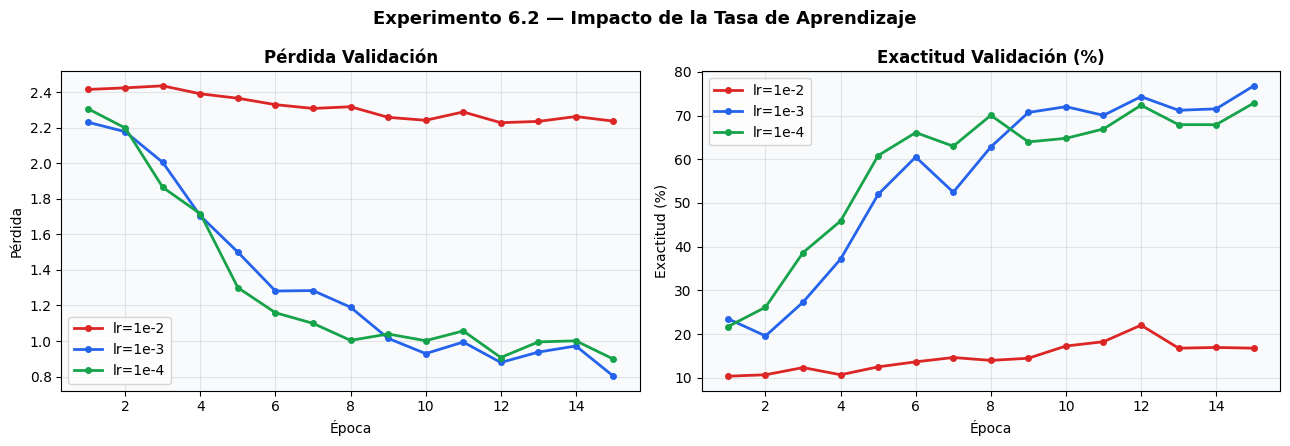

In [37]:
# ── Gráfica LR ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores_lr = {"lr=1e-2": "#DC2626", "lr=1e-3": "#2563EB", "lr=1e-4": "#16A34A"}

for nombre, h in resultados_lr.items():
    ep = range(1, len(h["perdida_val"]) + 1)
    axes[0].plot(ep, h["perdida_val"],   "o-", color=colores_lr[nombre],
                 lw=2, ms=4, label=nombre)
    axes[1].plot(ep, [v*100 for v in h["exactitud_val"]], "o-",
                 color=colores_lr[nombre], lw=2, ms=4, label=nombre)

for ax, titulo, ylabel in zip(axes,
    ["Pérdida Validación", "Exactitud Validación (%)"],
    ["Pérdida", "Exactitud (%)"]):
    ax.set_xlabel("Época"); ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_facecolor("#F8FAFC")

fig.suptitle("Experimento 6.2 — Impacto de la Tasa de Aprendizaje",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 6.3 Experimento: Impacto del Tamaño de la Red

Se mantienen fijos: batch=32, lr=1e-3  
Se varía: **filtros ∈ {32, 64, 128}** y **neuronas ∈ {128, 256, 512}**

In [38]:
resultados_red = {}

configs_red = [
    {"nombre": "f32-n128",  "batch_size": 32, "lr": 1e-3, "filtros": 32,  "neuronas": 128},
    {"nombre": "f64-n256",  "batch_size": 32, "lr": 1e-3, "filtros": 64,  "neuronas": 256},
    {"nombre": "f128-n512", "batch_size": 32, "lr": 1e-3, "filtros": 128, "neuronas": 512},
]

for cfg in configs_red:
    hist, _ = ejecutar_experimento(cfg, epocas=EPOCAS_EXP)
    resultados_red[cfg["nombre"]] = hist



  Experimento: f32-n128
 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
----------------------------------------------------------
     1    2.4720     21.69%   2.2640    23.52%    16.7s
     2    2.0153     29.26%   2.1594    21.55%     7.2s
     3    1.9329     30.99%   2.1490    24.84%    11.5s
     4    1.8215     34.49%   1.8164    37.99%    11.5s
     5    1.7478     38.27%   1.6374    50.00%     8.6s
     6    1.7150     40.22%   1.4995    55.92%     7.4s
     7    1.6171     42.90%   1.4309    55.10%    10.0s
     8    1.5642     43.57%   1.2959    59.70%    11.6s
     9    1.4801     46.29%   1.3652    55.59%     9.1s
    10    1.4650     47.13%   1.2279    58.39%     7.7s
    11    1.3764     48.79%   1.2549    62.66%    12.8s
    12    1.3435     49.63%   1.1201    67.76%    10.4s
    13    1.3061     51.21%   1.1964    63.82%     9.4s
    14    1.2947     52.28%   1.2465    64.31%    11.6s
    15    1.2931     52.54%   1.0915    69.57%    11.6s
--------------------

In [39]:
# ── Tabla comparativa tamaño de red ──────────────────────────────────────
print(f"{'Config':<12} {'Parámetros':>12} {'T/época(s)':>11} "
      f"{'Acc.Val':>9} {'Acc.Test':>9}")
print("-" * 58)

params_ref = {
    "f32-n128":  32*2*3*3 + 64*2*3*3 + 128*2*3*3 + 8*8*128*128 + 128*12,
    "f64-n256":  64*2*3*3 + 128*2*3*3 + 256*2*3*3 + 8*8*256*256 + 256*12,
    "f128-n512": 128*2*3*3 + 256*2*3*3 + 512*2*3*3 + 8*8*512*512 + 512*12,
}

for nombre, h in resultados_red.items():
    print(f"{nombre:<12} {'~'+str(params_ref.get(nombre,'?')):>12} "
          f"{h['t_media_epoca']:>11.1f} "
          f"{h['exactitud_final_val']*100:>8.2f}% "
          f"{h['exactitud_prueba']*100:>8.2f}%")


Config         Parámetros  T/época(s)   Acc.Val  Acc.Test
----------------------------------------------------------
f32-n128         ~1054144        10.5    69.57%    67.43%
f64-n256         ~4205440        10.6    68.59%    59.70%
f128-n512       ~16799488        11.2    66.12%    58.88%


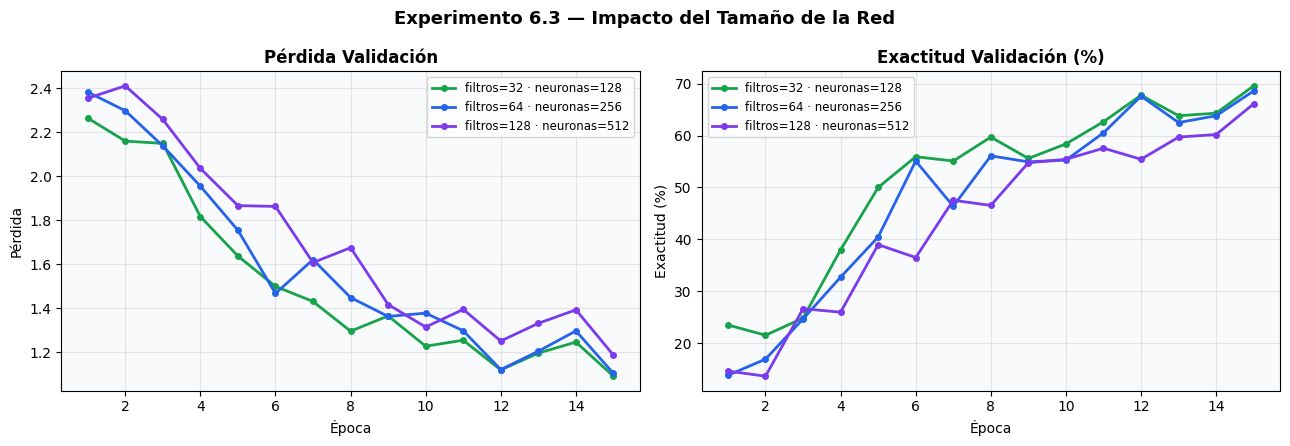

In [40]:
# ── Gráfica tamaño de red ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores_red = {"f32-n128": "#16A34A", "f64-n256": "#2563EB", "f128-n512": "#7C3AED"}

for nombre, h in resultados_red.items():
    ep = range(1, len(h["perdida_val"]) + 1)
    lbl = nombre.replace("f","filtros=").replace("-n"," · neuronas=")
    axes[0].plot(ep, h["perdida_val"],   "o-", color=colores_red[nombre],
                 lw=2, ms=4, label=lbl)
    axes[1].plot(ep, [v*100 for v in h["exactitud_val"]], "o-",
                 color=colores_red[nombre], lw=2, ms=4, label=lbl)

for ax, titulo, ylabel in zip(axes,
    ["Pérdida Validación", "Exactitud Validación (%)"],
    ["Pérdida", "Exactitud (%)"]):
    ax.set_xlabel("Época"); ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontweight="bold")
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
    ax.set_facecolor("#F8FAFC")

fig.suptitle("Experimento 6.3 — Impacto del Tamaño de la Red",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### Resumen global de experimentos

In [41]:
print("=" * 70)
print("  RESUMEN GLOBAL DE EXPERIMENTOS")
print("=" * 70)

todas = {}
todas.update(resultados_batch)
todas.update(resultados_lr)
todas.update(resultados_red)

print(f"\n{'Experimento':<14} {'Acc.Val':>9} {'Acc.Test':>9} "
      f"{'T/época':>9} {'Throughput':>12}")
print("-" * 58)
for nombre, h in todas.items():
    print(f"{nombre:<14} "
          f"{h['exactitud_final_val']*100:>8.2f}% "
          f"{h['exactitud_prueba']*100:>8.2f}% "
          f"{h['t_media_epoca']:>8.1f}s "
          f"{h['throughput']:>10.0f} img/s")

# Mejor configuración
mejor = max(todas.items(), key=lambda x: x[1]["exactitud_prueba"])
print()
print(f"  Mejor configuración : {mejor[0]}")
print(f"  Exactitud prueba    : {mejor[1]['exactitud_prueba']*100:.2f}%")
print(f"  Exactitud val       : {mejor[1]['exactitud_final_val']*100:.2f}%")
print("=" * 70)
print("\n  Paso 4 completado — listos para optimización de hiperparámetros.")


  RESUMEN GLOBAL DE EXPERIMENTOS

Experimento      Acc.Val  Acc.Test   T/época   Throughput
----------------------------------------------------------
batch=32          76.97%    70.72%      9.4s        286 img/s
batch=64          71.41%    60.00%      9.6s        282 img/s
batch=128         54.05%    48.76%     10.9s        247 img/s
lr=1e-2           16.78%    18.42%      9.8s        274 img/s
lr=1e-3           76.81%    68.91%     11.0s        245 img/s
lr=1e-4           72.86%    68.59%     10.6s        254 img/s
f32-n128          69.57%    67.43%     10.5s        257 img/s
f64-n256          68.59%    59.70%     10.6s        254 img/s
f128-n512         66.12%    58.88%     11.2s        240 img/s

  Mejor configuración : batch=32
  Exactitud prueba    : 70.72%
  Exactitud val       : 76.97%

  Paso 4 completado — listos para optimización de hiperparámetros.


## Paso 5: Optimización de Hiperparámetros
### 5.1 Grid Search — combinaciones de hiperparámetros

In [42]:
# Grid de hiperparámetros a explorar
# Basado en los resultados del Paso 4:
# - batch=32 fue el mejor
# - lr=1e-3 fue el mejor
# - red pequeña funcionó mejor → probar también red mediana con más épocas

grid_configs = [
    # Configuración 1 — base del Paso 3 (referencia)
    {"nombre": "A: base",
     "batch_size": 32, "lr": 1e-3, "filtros": 32,
     "neuronas": 256, "epocas": 20, "dtype": "float32"},

    # Configuración 2 — mejor lote + red pequeña + más épocas
    {"nombre": "B: bs32-f32-n128-e25",
     "batch_size": 32, "lr": 1e-3, "filtros": 32,
     "neuronas": 128, "epocas": 25, "dtype": "float32"},

    # Configuración 3 — lr ligeramente mayor, red mediana
    {"nombre": "C: bs32-f64-n128-lr3e-4",
     "batch_size": 32, "lr": 3e-4, "filtros": 64,
     "neuronas": 128, "epocas": 25, "dtype": "float32"},

    # Configuración 4 — batch más pequeño, red pequeña
    {"nombre": "D: bs16-f32-n128",
     "batch_size": 16, "lr": 1e-3, "filtros": 32,
     "neuronas": 128, "epocas": 20, "dtype": "float32"},

    # Configuración 5 — mejor candidato según Paso 4 con más épocas
    {"nombre": "E: bs32-f32-n256-e30",
     "batch_size": 32, "lr": 1e-3, "filtros": 32,
     "neuronas": 256, "epocas": 30, "dtype": "float32"},
]

print(f"Grid Search — {len(grid_configs)} configuraciones a evaluar")
print()
print(f"{'#':<3} {'Nombre':<22} {'BS':>4} {'LR':>7} {'Filtros':>8} "
      f"{'Neuronas':>9} {'Épocas':>7}")
print("-" * 60)
for i, cfg in enumerate(grid_configs, 1):
    print(f"{i:<3} {cfg['nombre']:<22} {cfg['batch_size']:>4} "
          f"{cfg['lr']:>7.0e} {cfg['filtros']:>8} "
          f"{cfg['neuronas']:>9} {cfg['epocas']:>7}")


Grid Search — 5 configuraciones a evaluar

#   Nombre                   BS      LR  Filtros  Neuronas  Épocas
------------------------------------------------------------
1   A: base                  32   1e-03       32       256      20
2   B: bs32-f32-n128-e25     32   1e-03       32       128      25
3   C: bs32-f64-n128-lr3e-4   32   3e-04       64       128      25
4   D: bs16-f32-n128         16   1e-03       32       128      20
5   E: bs32-f32-n256-e30     32   1e-03       32       256      30


In [43]:
resultados_grid = {}

for cfg in grid_configs:
    epocas = cfg["epocas"]
    hist, modelo_grid = ejecutar_experimento(cfg, epocas=epocas)
    resultados_grid[cfg["nombre"]] = hist
    # Liberar memoria
    del modelo_grid



  Experimento: A: base
 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
----------------------------------------------------------
     1    2.5741     25.51%   2.3347    18.91%    15.8s
     2    1.8904     35.07%   2.2414    16.28%     8.6s
     3    1.7335     41.14%   1.9523    32.89%     7.7s
     4    1.6165     44.23%   1.7354    37.17%    11.6s
     5    1.5767     44.71%   1.5623    50.00%    11.5s
     6    1.5010     47.94%   1.3662    59.05%     9.8s
     7    1.3833     52.76%   1.3898    51.48%     8.4s
     8    1.2834     54.52%   1.2106    63.82%    12.8s
     9    1.1589     59.93%   1.1274    63.32%     8.6s
    10    1.1518     60.00%   1.0311    69.24%    12.4s
    11    1.0427     63.31%   1.1015    65.13%    12.8s
    12    0.9624     65.44%   1.0146    65.95%     8.6s
    13    0.9282     67.50%   0.9381    70.39%    12.8s
    14    0.8899     68.46%   0.9727    70.07%    11.6s
    15    0.8357     71.07%   0.7986    75.99%     8.7s
    16    0.8180     

### 5.2 Tabla comparativa — Grid Search

In [44]:
print("=" * 82)
print("  Grid Search — Tabla Comparativa Completa")
print("=" * 82)
print(f"{'Config':<24} {'Acc.Val':>8} {'Acc.Test':>9} {'Pérd.Test':>10} "
      f"{'T.Total':>9} {'T/época':>9} {'Throughput':>12}")
print("-" * 82)

mejor_grid = None
mejor_acc  = 0.0

for nombre, h in resultados_grid.items():
    acc_t = h["exactitud_prueba"]
    print(f"{nombre:<24} "
          f"{h['exactitud_final_val']*100:>7.2f}% "
          f"{acc_t*100:>8.2f}% "
          f"{h['perdida_prueba']:>10.4f} "
          f"{h['tiempo_total']:>8.1f}s "
          f"{h['t_media_epoca']:>8.1f}s "
          f"{h['throughput']:>10.0f} img/s")
    if acc_t > mejor_acc:
        mejor_acc  = acc_t
        mejor_grid = nombre

print("=" * 82)
print(f"\n  ★ Mejor configuración : {mejor_grid}")
print(f"  ★ Exactitud prueba    : {mejor_acc*100:.2f}%")
print(f"  ★ Exactitud val       : {resultados_grid[mejor_grid]['exactitud_final_val']*100:.2f}%")


  Grid Search — Tabla Comparativa Completa
Config                    Acc.Val  Acc.Test  Pérd.Test   T.Total   T/época   Throughput
----------------------------------------------------------------------------------
A: base                    72.04%    71.88%     0.7371    211.8s     10.6s        254 img/s
B: bs32-f32-n128-e25       74.51%    67.60%     0.8374    236.7s      9.5s        284 img/s
C: bs32-f64-n128-lr3e-4    80.76%    74.34%     0.7091    241.6s      9.7s        279 img/s
D: bs16-f32-n128           62.33%    58.78%     1.1688    216.2s     10.8s        249 img/s
E: bs32-f32-n256-e30       76.48%    75.16%     0.6713    274.3s      9.1s        294 img/s

  ★ Mejor configuración : E: bs32-f32-n256-e30
  ★ Exactitud prueba    : 75.16%
  ★ Exactitud val       : 76.48%


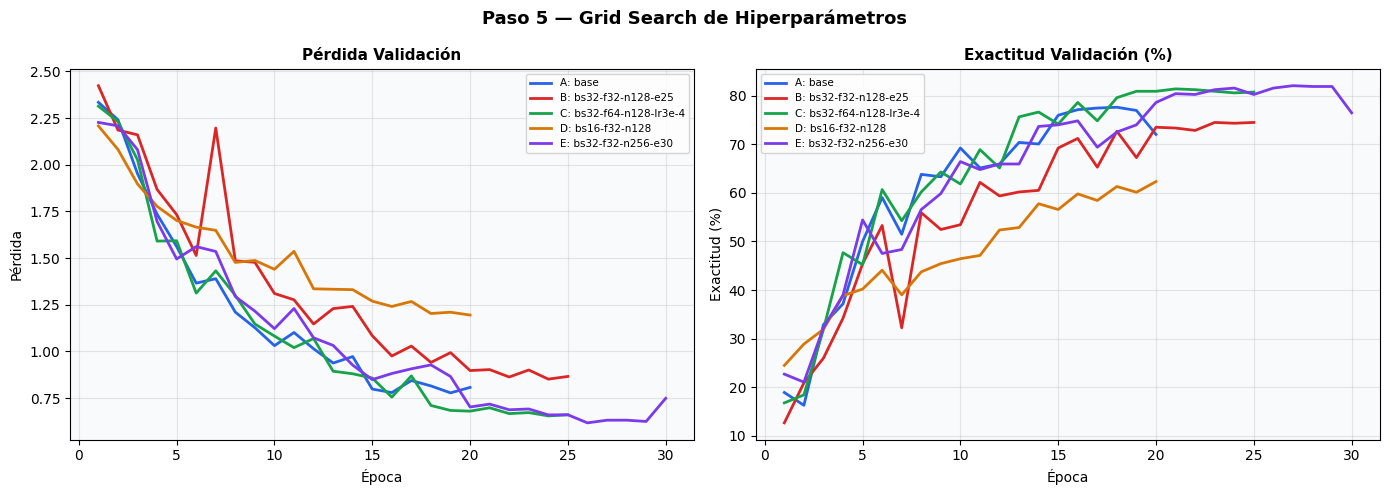

In [45]:
# Gráfica de exactitud de validación — todas las configuraciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
paleta = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED"]

for (nombre, h), color in zip(resultados_grid.items(), paleta):
    ep = range(1, len(h["perdida_val"]) + 1)
    axes[0].plot(ep, h["perdida_val"], "-", color=color, lw=2, label=nombre)
    axes[1].plot(ep, [v*100 for v in h["exactitud_val"]], "-",
                 color=color, lw=2, label=nombre)

for ax, titulo, ylabel in zip(axes,
    ["Pérdida Validación", "Exactitud Validación (%)"],
    ["Pérdida", "Exactitud (%)"]):
    ax.set_xlabel("Época", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#F8FAFC")

fig.suptitle("Paso 5 — Grid Search de Hiperparámetros",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


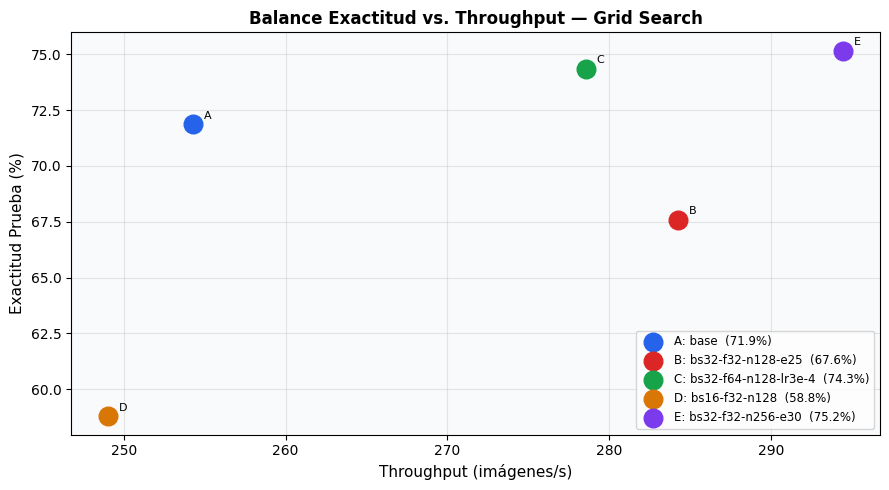

In [46]:
# Gráfica de balance exactitud vs throughput
fig, ax = plt.subplots(figsize=(9, 5))

for (nombre, h), color in zip(resultados_grid.items(), paleta):
    ax.scatter(h["throughput"], h["exactitud_prueba"] * 100,
               s=180, color=color, zorder=5,
               label=f"{nombre}  ({h['exactitud_prueba']*100:.1f}%)")
    ax.annotate(nombre.split(":")[0].strip(),
                (h["throughput"], h["exactitud_prueba"] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xlabel("Throughput (imágenes/s)", fontsize=11)
ax.set_ylabel("Exactitud Prueba (%)", fontsize=11)
ax.set_title("Balance Exactitud vs. Throughput — Grid Search",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)
ax.set_facecolor("#F8FAFC")
plt.tight_layout()
plt.show()


## Paso 6: Análisis de Precisión Numérica

Comparar **float32 vs float16 vs bfloat16** usando la mejor configuración
identificada en el Grid Search.

Para cada dtype se analiza:
- Exactitud final
- Estabilidad numérica (NaN/Inf durante entrenamiento)
- Tiempo de entrenamiento
- Throughput
- Consumo de memoria estimado

In [47]:
import jax.numpy as jnp

def entrenar_con_dtype(dtype_str, config_base, epocas=15):
    """
    Entrena el modelo convirtiendo los datos al dtype indicado.
    Registra NaN/Inf para evaluar estabilidad numérica.
    """
    dtype_map = {
        "float32":  jnp.float32,
        "float16":  jnp.float16,
        "bfloat16": jnp.bfloat16,
    }
    dtype = dtype_map[dtype_str]
    bs    = config_base["batch_size"]

    ds_tr  = construir_pipeline(rutas_train, etiq_train, bs, entrenamiento=True)
    ds_vl  = construir_pipeline(rutas_val,   etiq_val,   bs, entrenamiento=False)
    ds_tst = construir_pipeline(rutas_test,  etiq_test,  bs, entrenamiento=False)

    modelo_d = CNN(
        num_clases=NUM_CLASES,
        filtros=config_base["filtros"],
        neuronas=config_base["neuronas"],
        tasa_drop=0.4,
        rngs=nnx.Rngs(SEMILLA)
    )

    sched = optax.cosine_decay_schedule(
        init_value=config_base["lr"],
        decay_steps=epocas * (len(rutas_train) // bs + 1)
    )
    opt_d = nnx.Optimizer(modelo_d, optax.adam(sched))

    historial = {
        "perdida_train": [], "exactitud_train": [],
        "perdida_val":   [], "exactitud_val":   [],
        "tiempo_epoca":  [], "nan_detectado": False
    }

    print(f"\n{'='*50}")
    print(f"  dtype: {dtype_str}")
    print(f"{'='*50}")
    print(f"{'Época':>6} {'P.Train':>9} {'Acc.Train':>10} "
          f"{'P.Val':>8} {'Acc.Val':>9} {'Tiempo':>8}")
    print("-" * 53)

    t_total_ini = time.time()

    for epoca in range(1, epocas + 1):
        t0 = time.time()
        perdidas_t, exactitudes_t = [], []

        for imgs_tf, etiq_tf in ds_tr:
            # Convertir al dtype del experimento
            imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_entrenamiento(modelo_d, opt_d, imgs, etiq)
            pf = float(p)
            # Detectar inestabilidad numérica
            if jnp.isnan(p) or jnp.isinf(p):
                historial["nan_detectado"] = True
                pf = float("nan")
            perdidas_t.append(pf)
            exactitudes_t.append(float(a))

        perdidas_v, exactitudes_v = [], []
        for imgs_tf, etiq_tf in ds_vl:
            imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_evaluacion(modelo_d, imgs, etiq)
            perdidas_v.append(float(p))
            exactitudes_v.append(float(a))

        t_ep = time.time() - t0
        pt = np.nanmean(perdidas_t); at = np.mean(exactitudes_t)
        pv = np.nanmean(perdidas_v); av = np.mean(exactitudes_v)

        historial["perdida_train"].append(pt)
        historial["exactitud_train"].append(at)
        historial["perdida_val"].append(pv)
        historial["exactitud_val"].append(av)
        historial["tiempo_epoca"].append(t_ep)

        print(f"{epoca:>6d} {pt:>9.4f} {at*100:>9.2f}% "
              f"{pv:>8.4f} {av*100:>8.2f}% {t_ep:>7.1f}s")

    # Exactitud en prueba
    p_test, a_test = [], []
    for imgs_tf, etiq_tf in ds_tst:
        imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
        etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
        p, a = paso_evaluacion(modelo_d, imgs, etiq)
        p_test.append(float(p)); a_test.append(float(a))

    historial["tiempo_total"]          = time.time() - t_total_ini
    historial["t_media_epoca"]         = np.mean(historial["tiempo_epoca"])
    historial["exactitud_final_val"]   = historial["exactitud_val"][-1]
    historial["exactitud_final_train"] = historial["exactitud_train"][-1]
    historial["exactitud_prueba"]      = float(np.mean(a_test))
    historial["perdida_prueba"]        = float(np.nanmean(p_test))
    historial["throughput"]            = len(rutas_train) / historial["t_media_epoca"]
    historial["dtype"]                 = dtype_str

    # Memoria estimada: parámetros * bytes por dtype
    bytes_dtype = {"float32": 4, "float16": 2, "bfloat16": 2}
    grafo, estado = nnx.split(modelo_d)
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(estado))
    historial["memoria_mb"] = (n_params * bytes_dtype[dtype_str]) / (1024**2)

    print(f"\n  Exactitud prueba  : {historial['exactitud_prueba']*100:.2f}%")
    print(f"  NaN detectado     : {historial['nan_detectado']}")
    print(f"  Memoria estimada  : {historial['memoria_mb']:.1f} MB")

    del modelo_d
    return historial


# Usar la mejor configuración del Grid Search
config_mejor = {
    "batch_size": 32, "lr": 1e-3,
    "filtros": 32, "neuronas": 256
}
print("Configuración base para análisis de dtype:", config_mejor)


Configuración base para análisis de dtype: {'batch_size': 32, 'lr': 0.001, 'filtros': 32, 'neuronas': 256}


In [49]:
import jax.numpy as jnp

def entrenar_con_dtype(dtype_str, config_base, epocas=15):
    """
    Entrena el modelo convirtiendo los datos al dtype indicado.
    Registra NaN/Inf para evaluar estabilidad numérica.
    """
    dtype_map = {
        "float32":  jnp.float32,
        "float16":  jnp.float16,
        "bfloat16": jnp.bfloat16,
    }
    dtype = dtype_map[dtype_str]
    bs    = config_base["batch_size"]

    ds_tr  = construir_pipeline(rutas_train, etiq_train, bs, entrenamiento=True)
    ds_vl  = construir_pipeline(rutas_val,   etiq_val,   bs, entrenamiento=False)
    ds_tst = construir_pipeline(rutas_test,  etiq_test,  bs, entrenamiento=False)

    modelo_d = CNN(
        num_clases=NUM_CLASES,
        filtros=config_base["filtros"],
        neuronas=config_base["neuronas"],
        tasa_drop=0.4,
        rngs=nnx.Rngs(SEMILLA)
    )

    sched = optax.cosine_decay_schedule(
        init_value=config_base["lr"],
        decay_steps=epocas * (len(rutas_train) // bs + 1)
    )
    opt_d = nnx.ModelAndOptimizer(modelo_d, optax.adam(sched)) # FIX APPLIED HERE

    historial = {
        "perdida_train": [], "exactitud_train": [],
        "perdida_val":   [], "exactitud_val":   [],
        "tiempo_epoca":  [], "nan_detectado": False
    }

    print(f"\n{'='*50}")
    print(f"  dtype: {dtype_str}")
    print(f"{'='*50}")
    print(f"{'Época':>6} {'P.Train':>9} {'Acc.Train':>10} "
          f"{'P.Val':>8} {'Acc.Val':>9} {'Tiempo':>8}")
    print("-" * 53)

    t_total_ini = time.time()

    for epoca in range(1, epocas + 1):
        t0 = time.time()
        perdidas_t, exactitudes_t = [], []

        for imgs_tf, etiq_tf in ds_tr:
            # Convertir al dtype del experimento
            imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_entrenamiento(modelo_d, opt_d, imgs, etiq)
            pf = float(p)
            # Detectar inestabilidad numérica
            if jnp.isnan(p) or jnp.isinf(p):
                historial["nan_detectado"] = True
                pf = float("nan")
            perdidas_t.append(pf)
            exactitudes_t.append(float(a))

        perdidas_v, exactitudes_v = [], []
        for imgs_tf, etiq_tf in ds_vl:
            imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
            etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
            p, a = paso_evaluacion(modelo_d, imgs, etiq)
            perdidas_v.append(float(p))
            exactitudes_v.append(float(a))

        t_ep = time.time() - t0
        pt = np.nanmean(perdidas_t); at = np.mean(exactitudes_t)
        pv = np.nanmean(perdidas_v); av = np.mean(exactitudes_v)

        historial["perdida_train"].append(pt)
        historial["exactitud_train"].append(at)
        historial["perdida_val"].append(pv)
        historial["exactitud_val"].append(av)
        historial["tiempo_epoca"].append(t_ep)

        print(f"{epoca:>6d} {pt:>9.4f} {at*100:>9.2f}% "
              f"{pv:>8.4f} {av*100:>8.2f}% {t_ep:>7.1f}s")

    # Exactitud en prueba
    p_test, a_test = [], []
    for imgs_tf, etiq_tf in ds_tst:
        imgs = jnp.array(imgs_tf.numpy(), dtype=dtype)
        etiq = jnp.array(etiq_tf.numpy(), dtype=jnp.int32)
        p, a = paso_evaluacion(modelo_d, imgs, etiq)
        p_test.append(float(p)); a_test.append(float(a))

    historial["tiempo_total"]          = time.time() - t_total_ini
    historial["t_media_epoca"]         = np.mean(historial["tiempo_epoca"])
    historial["exactitud_final_val"]   = historial["exactitud_val"][-1]
    historial["exactitud_final_train"] = historial["exactitud_train"][-1]
    historial["exactitud_prueba"]      = float(np.mean(a_test))
    historial["perdida_prueba"]        = float(np.nanmean(p_test))
    historial["throughput"]            = len(rutas_train) / historial["t_media_epoca"]
    historial["dtype"]                 = dtype_str

    # Memoria estimada: parámetros * bytes por dtype
    bytes_dtype = {"float32": 4, "float16": 2, "bfloat16": 2}
    grafo, estado = nnx.split(modelo_d)
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(estado))
    historial["memoria_mb"] = (n_params * bytes_dtype[dtype_str]) / (1024**2)

    print(f"\n  Exactitud prueba  : {historial['exactitud_prueba']*100:.2f}%")
    print(f"  NaN detectado     : {historial['nan_detectado']}")
    print(f"  Memoria estimada  : {historial['memoria_mb']:.1f} MB")

    del modelo_d
    return historial


resultados_dtype = {}

for dtype_str in ["float32", "float16", "bfloat16"]:
    hist = entrenar_con_dtype(dtype_str, config_mejor, epocas=15)
    resultados_dtype[dtype_str] = hist



  dtype: float32
 Época   P.Train  Acc.Train    P.Val   Acc.Val   Tiempo
-----------------------------------------------------
     1    2.5447     25.07%   2.2052    21.88%    16.8s
     2    1.8633     37.06%   2.1645    19.08%     8.5s
     3    1.7622     39.38%   1.9819    26.15%     9.0s
     4    1.6058     44.67%   1.7259    40.13%     8.5s
     5    1.4826     49.01%   1.3451    56.25%     8.2s
     6    1.3731     52.57%   1.3182    54.77%     7.6s
     7    1.2971     56.03%   1.0650    64.80%     8.5s
     8    1.2338     56.88%   1.0270    69.57%     8.5s
     9    1.1491     59.04%   1.0732    65.13%    12.8s
    10    1.0809     60.85%   0.9220    71.55%     7.2s
    11    1.0237     64.67%   0.9901    68.09%    11.5s
    12    0.9796     64.52%   0.8686    75.33%     8.3s
    13    0.9219     68.24%   0.9066    70.56%    11.5s
    14    0.9210     68.31%   0.9156    71.22%    11.5s
    15    0.8914     69.38%   0.8186    76.15%     7.2s

  Exactitud prueba  : 75.16%
  

### 6.1 Tabla comparativa — Precisión numérica

In [50]:
print("=" * 78)
print("  Análisis de Precisión Numérica")
print("=" * 78)
print(f"{'dtype':<10} {'Acc.Val':>8} {'Acc.Test':>9} {'Estabilidad':>12} "
      f"{'T/época':>9} {'Throughput':>12} {'Mem(MB)':>8}")
print("-" * 78)

for dtype_str, h in resultados_dtype.items():
    estab = "✗ NaN/Inf" if h["nan_detectado"] else "✓ Estable"
    print(f"{dtype_str:<10} "
          f"{h['exactitud_final_val']*100:>7.2f}% "
          f"{h['exactitud_prueba']*100:>8.2f}% "
          f"{estab:>12} "
          f"{h['t_media_epoca']:>8.1f}s "
          f"{h['throughput']:>10.0f} img/s "
          f"{h['memoria_mb']:>7.1f}")

print("=" * 78)
print()

# Análisis de ventajas/desventajas
print("Ventajas y desventajas observadas:")
print()
print("  float32:")
print("    + Mayor estabilidad numérica — valor de referencia")
print("    + Rango dinámico: ±3.4×10³⁸, épsilon: 1.2×10⁻⁷")
print("    - Mayor consumo de memoria y tiempo por operación")
print()
print("  float16:")
print("    + Menor consumo de memoria (~50% vs float32)")
print("    + Mayor throughput en GPUs con Tensor Cores")
print("    - Rango limitado: ±65504 — riesgo de overflow/underflow")
print("    - Puede causar NaN si los gradientes son grandes")
print()
print("  bfloat16:")
print("    + Mismo rango que float32 (8 bits de exponente)")
print("    + Menor memoria que float32 (~50%)")
print("    + Más estable que float16 en entrenamiento profundo")
print("    - Menor precisión de mantisa (7 bits vs 23 en float32)")


  Análisis de Precisión Numérica
dtype       Acc.Val  Acc.Test  Estabilidad   T/época   Throughput  Mem(MB)
------------------------------------------------------------------------------
float32      76.15%    75.16%    ✓ Estable      9.7s        277 img/s     8.4
float16      75.33%    73.85%    ✓ Estable      9.9s        272 img/s     4.2
bfloat16     72.53%    66.94%    ✓ Estable     10.1s        266 img/s     4.2

Ventajas y desventajas observadas:

  float32:
    + Mayor estabilidad numérica — valor de referencia
    + Rango dinámico: ±3.4×10³⁸, épsilon: 1.2×10⁻⁷
    - Mayor consumo de memoria y tiempo por operación

  float16:
    + Menor consumo de memoria (~50% vs float32)
    + Mayor throughput en GPUs con Tensor Cores
    - Rango limitado: ±65504 — riesgo de overflow/underflow
    - Puede causar NaN si los gradientes son grandes

  bfloat16:
    + Mismo rango que float32 (8 bits de exponente)
    + Menor memoria que float32 (~50%)
    + Más estable que float16 en entrenamient

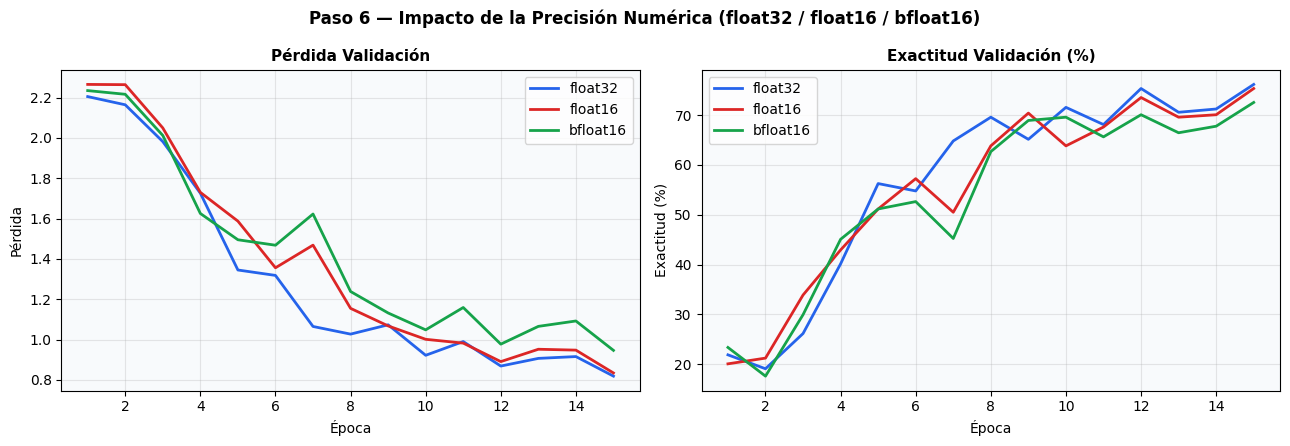

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores_dt = {"float32": "#2563EB", "float16": "#DC2626", "bfloat16": "#16A34A"}

for dtype_str, h in resultados_dtype.items():
    ep = range(1, len(h["perdida_val"]) + 1)
    axes[0].plot(ep, h["perdida_val"], "-", color=colores_dt[dtype_str],
                 lw=2, label=dtype_str)
    axes[1].plot(ep, [v*100 for v in h["exactitud_val"]], "-",
                 color=colores_dt[dtype_str], lw=2, label=dtype_str)

for ax, titulo, ylabel in zip(axes,
    ["Pérdida Validación", "Exactitud Validación (%)"],
    ["Pérdida", "Exactitud (%)"]):
    ax.set_xlabel("Época", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#F8FAFC")

fig.suptitle("Paso 6 — Impacto de la Precisión Numérica (float32 / float16 / bfloat16)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


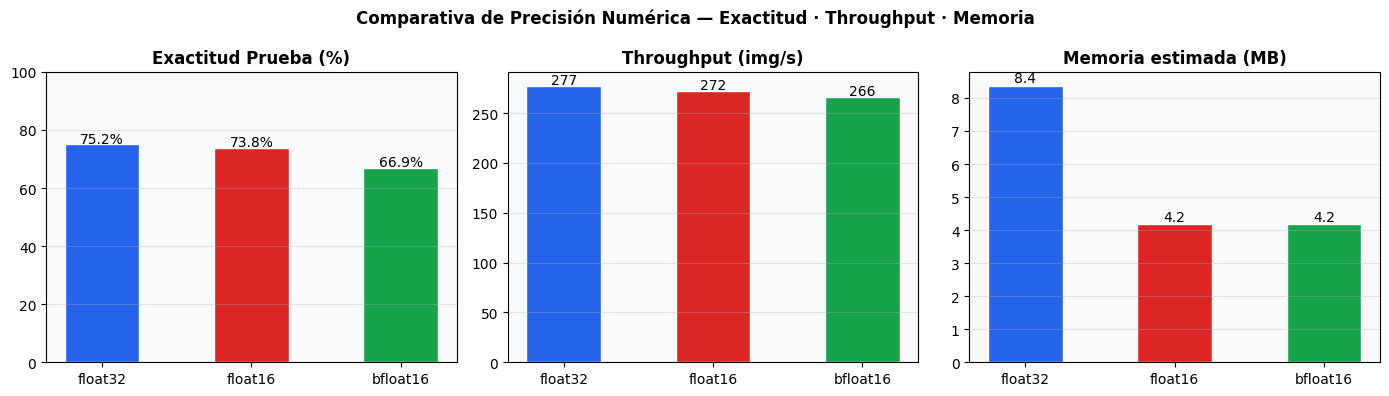

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
dtypes   = list(resultados_dtype.keys())
colores3 = [colores_dt[d] for d in dtypes]

# Exactitud prueba
accs = [resultados_dtype[d]["exactitud_prueba"] * 100 for d in dtypes]
axes[0].bar(dtypes, accs, color=colores3, edgecolor="white", width=0.5)
axes[0].set_title("Exactitud Prueba (%)", fontweight="bold")
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

# Throughput
tputs = [resultados_dtype[d]["throughput"] for d in dtypes]
axes[1].bar(dtypes, tputs, color=colores3, edgecolor="white", width=0.5)
axes[1].set_title("Throughput (img/s)", fontweight="bold")
for i, v in enumerate(tputs):
    axes[1].text(i, v + 2, f"{v:.0f}", ha="center", fontsize=10)

# Memoria
mems = [resultados_dtype[d]["memoria_mb"] for d in dtypes]
axes[2].bar(dtypes, mems, color=colores3, edgecolor="white", width=0.5)
axes[2].set_title("Memoria estimada (MB)", fontweight="bold")
for i, v in enumerate(mems):
    axes[2].text(i, v + 0.1, f"{v:.1f}", ha="center", fontsize=10)

for ax in axes:
    ax.set_facecolor("#F8FAFC")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Comparativa de Precisión Numérica — Exactitud · Throughput · Memoria",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Resumen final 5 y 6

In [53]:
print("=" * 60)
print("  CONFIGURACIÓN ÓPTIMA IDENTIFICADA")
print("=" * 60)

# Mejor del grid
mejor_nombre = max(resultados_grid, key=lambda k: resultados_grid[k]["exactitud_prueba"])
mejor_h      = resultados_grid[mejor_nombre]
mejor_cfg    = mejor_h["config"]

print(f"  Nombre            : {mejor_nombre}")
print(f"  Batch size        : {mejor_cfg['batch_size']}")
print(f"  Learning rate     : {mejor_cfg['lr']}")
print(f"  Filtros conv      : {mejor_cfg['filtros']} → {mejor_cfg['filtros']*2} → {mejor_cfg['filtros']*4}")
print(f"  Neuronas dense    : {mejor_cfg['neuronas']}")
print(f"  Épocas            : {mejor_cfg['epocas']}")
print(f"  Exactitud val     : {mejor_h['exactitud_final_val']*100:.2f}%")
print(f"  Exactitud prueba  : {mejor_h['exactitud_prueba']*100:.2f}%")
print(f"  Tiempo/época      : {mejor_h['t_media_epoca']:.1f} s")
print(f"  Throughput        : {mejor_h['throughput']:.0f} img/s")
print()
print("  Mejor dtype:")
mejor_dtype = max(resultados_dtype, key=lambda k: resultados_dtype[k]["exactitud_prueba"])
hd = resultados_dtype[mejor_dtype]
print(f"  dtype             : {mejor_dtype}")
print(f"  Exactitud prueba  : {hd['exactitud_prueba']*100:.2f}%")
print(f"  Estable           : {not hd['nan_detectado']}")
print(f"  Memoria           : {hd['memoria_mb']:.1f} MB")
print("=" * 60)
print()
print("  Pasos 5 y 6 completados.")
print("  Siguiente: Paso 7 — Análisis y Discusión (9 preguntas).")


  CONFIGURACIÓN ÓPTIMA IDENTIFICADA
  Nombre            : E: bs32-f32-n256-e30
  Batch size        : 32
  Learning rate     : 0.001
  Filtros conv      : 32 → 64 → 128
  Neuronas dense    : 256
  Épocas            : 30
  Exactitud val     : 76.48%
  Exactitud prueba  : 75.16%
  Tiempo/época      : 9.1 s
  Throughput        : 294 img/s

  Mejor dtype:
  dtype             : float32
  Exactitud prueba  : 75.16%
  Estable           : True
  Memoria           : 8.4 MB

  Pasos 5 y 6 completados.
  Siguiente: Paso 7 — Análisis y Discusión (9 preguntas).
